In [34]:
%run NewChartsCommon.ipynb

In [32]:
path = "./output-20-02/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(ndev)'

dfs=read_dfs(path,patterndevs, 2)
labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar1 = [dfs[('A1','ndev')], dfs[('A2','ndev')], dfs[('A3','ndev')]]
#print(dfsVar1)


merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)

merged_df_var1["online_to_offline_A1"] = merged_df_var1["ms_1_A1"]/merged_df_var1["ms_2_A1"]
merged_df_var1["offline_to_base_A1"] = merged_df_var1["ms_2_A1"]/merged_df_var1["ms_3_A1"]

print(merged_df_var1["online_to_offline_A1"].agg(gmean))
print(merged_df_var1["offline_to_base_A1"].agg(gmean))


patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs=read_dfs(path,patterndevs, 2)
labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar1 = [dfs[('A1','50dev')], dfs[('A2','50dev')], dfs[('A3','50dev')]]
#print(dfsVar1)


merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)

merged_df_var1["online_to_offline_A1"] = merged_df_var1["ms_1_A1"]/merged_df_var1["ms_2_A1"]
merged_df_var1["offline_to_base_A1"] = merged_df_var1["ms_2_A1"]/merged_df_var1["ms_3_A1"]

print(merged_df_var1["online_to_offline_A1"].agg(gmean))
print(merged_df_var1["offline_to_base_A1"].agg(gmean))



merged_df_var1['size_group'] = merged_df_var1['size'].apply(size_category)
# Filter only valid categories
filtered = merged_df_var1[merged_df_var1['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['size_group'])['online_to_offline_A1'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values([ 'size_group'])

print(result)

merged_df_var1 = merged_df_var1.sort_values('wf_name')

print(merged_df_var1[merged_df_var1[ 'size_group']=="small"][["wf_name", "inp_size", "size", "online_to_offline_A1"]])#["ms_1_A1"])



./output-20-02/merged/*.txt
0.7991616336169602
0.13693240699860906
0.7954733019699851
0.14651081545155561
  size_group  online_to_offline_A1
2      small              0.804844
1     middle              0.783832
0      large              0.839037
               wf_name      inp_size  size  online_to_offline_A1
40             atacseq   14091675276   100              0.367941
158            atacseq   11809629756   100              0.998602
111            atacseq   11187378708   100              1.044813
32             atacseq    3908761308   100              1.057575
145            atacseq    2223941232   100              1.234006
71     atacseq_200.dot   14091675276   200              0.377069
77     atacseq_200.dot    2223941232   200              1.108652
107    atacseq_200.dot   11187378708   200              1.037605
20     atacseq_200.dot   11809629756   200              2.675986
75     atacseq_200.dot    3908761308   200              1.104508
112            chipseq    5058052541   

In [54]:
path = "./output-1-03-26-2ndversion/merged/*.txt"
print(path)

print("\n-----------------\n Release enough to fill our processor\n")
patterndevs = r'^(BASE|A\d+)-(ndev~OurProc)'

dfs=read_dfs(path,patterndevs, 2)
#print(dfs)
labels = ['A1', 'A2', 'A3']
dfsVar1 = [dfs[('A1','ndev~OurProc')], dfs[('A2','ndev~OurProc')], dfs[('A3','ndev~OurProc')]]
#print(dfsVar1)

merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)

merged_df_var1["online_to_offline_A1"] = merged_df_var1["ms_1_A1"]/merged_df_var1["ms_2_A1"]
merged_df_var1["offline_to_base_A1"] = merged_df_var1["ms_2_A1"]/merged_df_var1["ms_3_A1"]

print("online_to_offline_A1", merged_df_var1["online_to_offline_A1"].agg(gmean))
print("online_to_offline_A1", merged_df_var1["offline_to_base_A1"].agg(gmean))


patterndevs = r'^(BASE|A\d+)-(\d\ddev~OurProc)'

dfs=read_dfs(path,patterndevs, 2)

dfsOurProc50 = [dfs[('A1','50dev~OurProc')], dfs[('A2','50dev~OurProc')], dfs[('A3','50dev~OurProc')]]
#print(dfsOurProc50)
#dfs[('A1','50dev~OurProc')].info()


merged_df_OurProc50= merge_correct_columns(dfsOurProc50, labels)
#print(merged_df_var1)

merged_df_OurProc50["online_to_offline_A1"] = merged_df_OurProc50["ms_1_A1"]/merged_df_OurProc50["ms_2_A1"]
merged_df_OurProc50["offline_to_base_A1"] = merged_df_OurProc50["ms_2_A1"]/merged_df_OurProc50["ms_3_A1"]

print("online_to_offline_A1 50-vars", merged_df_OurProc50["online_to_offline_A1"].agg(gmean))
print("offline_to_base_A1 50-vars",merged_df_OurProc50["offline_to_base_A1"].agg(gmean))



dfsVarOurProc30 = [dfs[('A1','30dev~OurProc')], dfs[('A2','30dev~OurProc')], dfs[('A3','30dev~OurProc')]]

merged_df_OurProc30= merge_correct_columns(dfsVarOurProc30, labels)
#print(merged_df_var1)

merged_df_OurProc30["online_to_offline_A1"] = merged_df_OurProc30["ms_1_A1"]/merged_df_OurProc30["ms_2_A1"]
merged_df_OurProc30["offline_to_base_A1"] = merged_df_OurProc30["ms_2_A1"]/merged_df_OurProc30["ms_3_A1"]

print("online_to_offline_A1 30-vars", merged_df_OurProc30["online_to_offline_A1"].agg(gmean))
print("offline_to_base_A1 30-vars",merged_df_OurProc30["offline_to_base_A1"].agg(gmean))


dfs=read_dfs(path,patterndevs, 2)
labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar1 = [dfs[('A1','10dev~OurProc')], dfs[('A2','10dev~OurProc')], dfs[('A3','10dev~OurProc')]]
#print(dfsVar1)


merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)

merged_df_var1["online_to_offline_A1"] = merged_df_var1["ms_1_A1"]/merged_df_var1["ms_2_A1"]
merged_df_var1["offline_to_base_A1"] = merged_df_var1["ms_2_A1"]/merged_df_var1["ms_3_A1"]

print("online_to_offline_A1 10-vars", merged_df_var1["online_to_offline_A1"].agg(gmean))
print("offline_to_base_A1 10-vars",merged_df_var1["offline_to_base_A1"].agg(gmean))





./output-1-03-26-2ndversion/merged/*.txt

-----------------
 Release enough to fill our processor

online_to_offline_A1 0.9730395587950502
online_to_offline_A1 0.15605667899583847
online_to_offline_A1 50-vars 0.9551005398659909
offline_to_base_A1 50-vars 0.16014692845082015
online_to_offline_A1 30-vars 0.9443872661879315
offline_to_base_A1 30-vars 0.16097471196829505
online_to_offline_A1 10-vars 0.9649697907720703
offline_to_base_A1 10-vars 0.15778911504444693


In [55]:





merged_df_var1['size_group'] = merged_df_var1['size'].apply(size_category)
# Filter only valid categories
filtered = merged_df_var1[merged_df_var1['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['size_group'])['online_to_offline_A1'].agg(gmean).reset_index()


# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values([ 'size_group'])

print("----------\nonline to offline, grouped by size:\n ", result, "\n------------\n")

merged_df_var1 = merged_df_var1.sort_values('wf_name')

print("nline to offline smalle 0.5:\n ", merged_df_var1[merged_df_var1[ 'online_to_offline_A1']<0.5][["wf_name", "inp_size", "size", "online_to_offline_A1"]])

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values([ 'size_group'])


----------
online to offline, grouped by size:
    size_group  online_to_offline_A1
2      small              1.044841
1     middle              0.923030
0      large              0.985349 
------------

nline to offline smalle 0.5:
                wf_name    inp_size  size  online_to_offline_A1
114  atacseq_1000.dot  2223941232  1000              0.167399
69    chipseq_200.dot  4605965334   200              0.027769
27    chipseq_200.dot  3793245764   200              0.090909


In [58]:
print("\n-----------------\n Release as many as number of processors\n")
patterndevs = r'^(BASE|A\d+)-(ndev~NumProc)'

dfs=read_dfs(path,patterndevs, 2)
#print(dfs)
labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar1 = [dfs[('A1','ndev~NumProc')], dfs[('A2','ndev~NumProc')], dfs[('A3','ndev~NumProc')]]
#print(dfsVar1)

merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)

merged_df_var1["online_to_offline_A1"] = merged_df_var1["ms_1_A1"]/merged_df_var1["ms_2_A1"]
merged_df_var1["offline_to_base_A1"] = merged_df_var1["ms_2_A1"]/merged_df_var1["ms_3_A1"]

print("online_to_offline_A1", merged_df_var1["online_to_offline_A1"].agg(gmean))
print("online_to_offline_A1", merged_df_var1["offline_to_base_A1"].agg(gmean))
print("gmean of offline makespans A1", merged_df_var1["ms_2_A1"].agg(gmean))
print("gmean of online makespans A1", merged_df_var1["ms_1_A1"].agg(gmean))


patterndevs = r'^(BASE|A\d+)-(\d\ddev~NumProc)'

dfs=read_dfs(path,patterndevs, 2)
labels = ['A1', 'A2', 'A3', 'BASE']
dfsA150dev = [dfs[('A1','50dev~NumProc')], dfs[('A2','50dev~NumProc')], dfs[('A3','50dev~NumProc')]]
#print(dfsVar1)


merged_df_A150dev = merge_correct_columns(dfsA150dev, labels)
#print(merged_df_var1)

merged_df_A150dev["online_to_offline_A1"] = merged_df_A150dev["ms_1_A1"]/merged_df_A150dev["ms_2_A1"]
merged_df_A150dev["offline_to_base_A1"] = merged_df_A150dev["ms_2_A1"]/merged_df_A150dev["ms_3_A1"]

print("online_to_offline_A1 50-vars", merged_df_A150dev["online_to_offline_A1"].agg(gmean))
print("offline_to_base_A1 50-vars",merged_df_A150dev["offline_to_base_A1"].agg(gmean))
print("gmean of offline makespans A1 50-vars", merged_df_A150dev["ms_2_A1"].agg(gmean))
print("gmean of online makespans A1 50-vars", merged_df_A150dev["ms_1_A1"].agg(gmean))


dfsVarOurProc30 = [dfs[('A1','30dev~NumProc')], dfs[('A2','30dev~NumProc')], dfs[('A3','30dev~NumProc')]]

merged_df_OurProc30= merge_correct_columns(dfsVarOurProc30, labels)
#print(merged_df_var1)

merged_df_OurProc30["online_to_offline_A1"] = merged_df_OurProc30["ms_1_A1"]/merged_df_OurProc30["ms_2_A1"]
merged_df_OurProc30["offline_to_base_A1"] = merged_df_OurProc30["ms_2_A1"]/merged_df_OurProc30["ms_3_A1"]

print("online_to_offline_A1 30-vars", merged_df_OurProc30["online_to_offline_A1"].agg(gmean))
print("offline_to_base_A1 30-vars",merged_df_OurProc30["offline_to_base_A1"].agg(gmean))


dfs=read_dfs(path,patterndevs, 2)
labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar1 = [dfs[('A1','10dev~NumProc')], dfs[('A2','10dev~NumProc')], dfs[('A3','10dev~NumProc')]]
#print(dfsVar1)


merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)

merged_df_var1["online_to_offline_A1"] = merged_df_var1["ms_1_A1"]/merged_df_var1["ms_2_A1"]
merged_df_var1["offline_to_base_A1"] = merged_df_var1["ms_2_A1"]/merged_df_var1["ms_3_A1"]

print("online_to_offline_A1 10-vars", merged_df_var1["online_to_offline_A1"].agg(gmean))
print("offline_to_base_A1 10-vars",merged_df_var1["offline_to_base_A1"].agg(gmean))



-----------------
 Release as many as number of processors

online_to_offline_A1 0.9297527505835045
online_to_offline_A1 0.15069838438507507
gmean of offline makespans A1 28677424.02199838
gmean of online makespans A1 26662913.864102438
online_to_offline_A1 50-vars 0.921514906440801
offline_to_base_A1 50-vars 0.15930159876802794
gmean of offline makespans A1 50-vars 29054575.768517334
gmean of online makespans A1 50-vars 26774224.671002388
online_to_offline_A1 30-vars 0.9048052982127636
offline_to_base_A1 30-vars 0.16057195889361553
online_to_offline_A1 10-vars 0.9329435613153536
offline_to_base_A1 10-vars 0.15736327706734377


In [49]:
print("\n-----------------\n Release all tasks\n")
patterndevs = r'^(BASE|A\d+)-(ndev~All)'

dfs=read_dfs(path,patterndevs, 2)
#print(dfs)
labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar1 = [dfs[('A1','ndev~All')], dfs[('A2','ndev~All')], dfs[('A3','ndev~All')]]
#print(dfsVar1)

merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)

merged_df_var1["online_to_offline_A1"] = merged_df_var1["ms_1_A1"]/merged_df_var1["ms_2_A1"]
merged_df_var1["offline_to_base_A1"] = merged_df_var1["ms_2_A1"]/merged_df_var1["ms_3_A1"]

print("online_to_offline_A1", merged_df_var1["online_to_offline_A1"].agg(gmean))
print("online_to_offline_A1", merged_df_var1["offline_to_base_A1"].agg(gmean))


patterndevs = r'^(BASE|A\d+)-(\d\ddev~All)'

dfs=read_dfs(path,patterndevs, 2)
labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar1 = [dfs[('A1','50dev~All')], dfs[('A2','50dev~All')], dfs[('A3','50dev~All')]]
#print(dfsVar1)


merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)

merged_df_var1["online_to_offline_A1"] = merged_df_var1["ms_1_A1"]/merged_df_var1["ms_2_A1"]
merged_df_var1["offline_to_base_A1"] = merged_df_var1["ms_2_A1"]/merged_df_var1["ms_3_A1"]

print("online_to_offline_A1 50-vars", merged_df_var1["online_to_offline_A1"].agg(gmean))
print("offline_to_base_A1 50-vars",merged_df_var1["offline_to_base_A1"].agg(gmean))

dfsVarOurProc30 = [dfs[('A1','30dev~All')], dfs[('A2','30dev~All')], dfs[('A3','30dev~All')]]

merged_df_OurProc30= merge_correct_columns(dfsVarOurProc30, labels)
#print(merged_df_var1)

merged_df_OurProc30["online_to_offline_A1"] = merged_df_OurProc30["ms_1_A1"]/merged_df_OurProc30["ms_2_A1"]
merged_df_OurProc30["offline_to_base_A1"] = merged_df_OurProc30["ms_2_A1"]/merged_df_OurProc30["ms_3_A1"]

print("online_to_offline_A1 30-vars", merged_df_OurProc30["online_to_offline_A1"].agg(gmean))
print("offline_to_base_A1 30-vars",merged_df_OurProc30["offline_to_base_A1"].agg(gmean))


dfs=read_dfs(path,patterndevs, 2)
labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar1 = [dfs[('A1','10dev~All')], dfs[('A2','10dev~All')], dfs[('A3','10dev~All')]]
#print(dfsVar1)


merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)

merged_df_var1["online_to_offline_A1"] = merged_df_var1["ms_1_A1"]/merged_df_var1["ms_2_A1"]
merged_df_var1["offline_to_base_A1"] = merged_df_var1["ms_2_A1"]/merged_df_var1["ms_3_A1"]

print("online_to_offline_A1 10-vars", merged_df_var1["online_to_offline_A1"].agg(gmean))
print("offline_to_base_A1 10-vars",merged_df_var1["offline_to_base_A1"].agg(gmean))


-----------------
 Release all tasks

online_to_offline_A1 0.9297527505835045
online_to_offline_A1 0.15069838438507507
online_to_offline_A1 50-vars 0.9206161111619521
offline_to_base_A1 50-vars 0.1595227449216307
online_to_offline_A1 30-vars 0.9119906502354681
offline_to_base_A1 30-vars 0.1623157332204591
online_to_offline_A1 10-vars 0.9236306912473056
offline_to_base_A1 10-vars 0.15722298602297136


In [57]:


print("\n-----------------\n Release enough to fill our processor, MEDIH-MM (A3)\n")
patterndevs = r'^(BASE|A\d+)-(ndev~OurProc)'

dfs=read_dfs(path,patterndevs, 2)
#print(dfs)
labels = ['A1', 'A2', 'A3']
dfsVar1 = [dfs[('A1','ndev~OurProc')], dfs[('A2','ndev~OurProc')], dfs[('A3','ndev~OurProc')]]
#print(dfsVar1)

merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)

merged_df_var1["online_to_offline_A3"] = merged_df_var1["ms_1_A3"]/merged_df_var1["ms_2_A3"]
merged_df_var1["offline_to_base_A3"] = merged_df_var1["ms_2_A3"]/merged_df_var1["ms_3_A3"]

print("online_to_offline_A3", merged_df_var1["online_to_offline_A3"].agg(gmean))
print("offline_to_base_A3_A3", merged_df_var1["offline_to_base_A3"].agg(gmean))


patterndevs = r'^(BASE|A\d+)-(\d\ddev~OurProc)'

dfs=read_dfs(path,patterndevs, 2)

dfsOurProc50 = [dfs[('A1','50dev~OurProc')], dfs[('A2','50dev~OurProc')], dfs[('A3','50dev~OurProc')]]
#print(dfsOurProc50)
#dfs[('A1','50dev~OurProc')].info()


merged_df_OurProc50= merge_correct_columns(dfsOurProc50, labels)
#print(merged_df_var1)

merged_df_OurProc50["online_to_offline_A3"] = merged_df_OurProc50["ms_1_A3"]/merged_df_OurProc50["ms_2_A3"]
merged_df_OurProc50["offline_to_base_A3"] = merged_df_OurProc50["ms_2_A3"]/merged_df_OurProc50["ms_3_A3"]

print("online_to_offline_A3 50-vars", merged_df_OurProc50["online_to_offline_A3"].agg(gmean))
print("offline_to_base_A3 50-vars",merged_df_OurProc50["offline_to_base_A3"].agg(gmean))


print("\nwrong after this ----------------- \n")


dfsVarOurProc30 = [dfs[('A1','30dev~OurProc')], dfs[('A2','30dev~OurProc')], dfs[('A3','30dev~OurProc')]]

merged_df_OurProc30= merge_correct_columns(dfsVarOurProc30, labels)
#print(merged_df_var1)

merged_df_OurProc30["online_to_offline_A1"] = merged_df_OurProc30["ms_1_A1"]/merged_df_OurProc30["ms_2_A1"]
merged_df_OurProc30["offline_to_base_A1"] = merged_df_OurProc30["ms_2_A1"]/merged_df_OurProc30["ms_3_A1"]

print("online_to_offline_A1 30-vars", merged_df_OurProc30["online_to_offline_A1"].agg(gmean))
print("offline_to_base_A1 30-vars",merged_df_OurProc30["offline_to_base_A1"].agg(gmean))


dfs=read_dfs(path,patterndevs, 2)
labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar1 = [dfs[('A1','10dev~OurProc')], dfs[('A2','10dev~OurProc')], dfs[('A3','10dev~OurProc')]]
#print(dfsVar1)


merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)

merged_df_var1["online_to_offline_A1"] = merged_df_var1["ms_1_A1"]/merged_df_var1["ms_2_A1"]
merged_df_var1["offline_to_base_A1"] = merged_df_var1["ms_2_A1"]/merged_df_var1["ms_3_A1"]

print("online_to_offline_A1 10-vars", merged_df_var1["online_to_offline_A1"].agg(gmean))
print("offline_to_base_A1 10-vars",merged_df_var1["offline_to_base_A1"].agg(gmean))


-----------------
 Release enough to fill our processor, MEDIH-MM (A3)

online_to_offline_A3 11.339108136203341
offline_to_base_A3_A3 0.01246842201608697
online_to_offline_A3 50-vars 11.893415184197888
offline_to_base_A3 50-vars 0.01191665171381742

wrong after this ----------------- 

online_to_offline_A1 30-vars 0.9443872661879315
offline_to_base_A1 30-vars 0.16097471196829505
online_to_offline_A1 10-vars 0.9649697907720703
offline_to_base_A1 10-vars 0.15778911504444693


In [52]:
path = "./output-6-03/merged/*.txt"
print(path)

print("\n-----------------\n 6-03 \n A1, all deviations \n  Release enough to fill our processor\n")
patterndevs = r'^(BASE|A\d+)-(ndev~OurProc,nonpr,norm)'

dfs=read_dfs(path,patterndevs, 2)
#print(dfs)
labels = ['A1', 'A2', 'A3', 'A4', 'A5']
dfsVar1 = [dfs[('A1','ndev~OurProc,nonpr,norm')], dfs[('A2','ndev~OurProc,nonpr,norm')], dfs[('A3','ndev~OurProc,nonpr,norm')]]
#print(dfsVar1)

merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)

merged_df_var1["online_to_offline_A1"] = merged_df_var1["ms_1_A1"]/merged_df_var1["ms_2_A1"]
merged_df_var1["offline_to_base_A1"] = merged_df_var1["ms_2_A1"]/merged_df_var1["ms_3_A1"]


#print(merged_df_var1[merged_df_var1['online_to_offline_A1']<0.7])

print("online_to_offline_A1", merged_df_var1["online_to_offline_A1"].agg(gmean))
print("offline_to_base_A1", merged_df_var1["offline_to_base_A1"].agg(gmean))


patterndevs = r'^(BASE|A\d+)-(\d\ddev~OurProc,nonpr,norm)'

dfs=read_dfs(path,patterndevs, 2)

dfsOurProc50 = [dfs[('A1','50dev~OurProc,nonpr,norm')], dfs[('A2','50dev~OurProc,nonpr,norm')], dfs[('A3','50dev~OurProc,nonpr,norm')]]
#print(dfsOurProc50)
#dfs[('A1','50dev~OurProc')].info()


merged_df_OurProc50= merge_correct_columns(dfsOurProc50, labels)
#print(merged_df_var1)

merged_df_OurProc50["online_to_offline_A1"] = merged_df_OurProc50["ms_1_A1"]/merged_df_OurProc50["ms_2_A1"]
merged_df_OurProc50["offline_to_base_A1"] = merged_df_OurProc50["ms_2_A1"]/merged_df_OurProc50["ms_3_A1"]

print("online_to_offline_A1 50-vars", merged_df_OurProc50["online_to_offline_A1"].agg(gmean))
print("offline_to_base_A1 50-vars",merged_df_OurProc50["offline_to_base_A1"].agg(gmean))



dfsVarOurProc30 = [dfs[('A1','30dev~OurProc,nonpr,norm')], dfs[('A2','30dev~OurProc,nonpr,norm')], dfs[('A3','30dev~OurProc,nonpr,norm')]]

merged_df_OurProc30= merge_correct_columns(dfsVarOurProc30, labels)
#print(merged_df_var1)

merged_df_OurProc30["online_to_offline_A1"] = merged_df_OurProc30["ms_1_A1"]/merged_df_OurProc30["ms_2_A1"]
merged_df_OurProc30["offline_to_base_A1"] = merged_df_OurProc30["ms_2_A1"]/merged_df_OurProc30["ms_3_A1"]

print("online_to_offline_A1 30-vars", merged_df_OurProc30["online_to_offline_A1"].agg(gmean))
print("offline_to_base_A1 30-vars",merged_df_OurProc30["offline_to_base_A1"].agg(gmean))


dfs=read_dfs(path,patterndevs, 2)
labels = ['A1', 'A2', 'A3', 'BASE']
dfsVarOurProc10 = [dfs[('A1','10dev~OurProc,nonpr,norm')], dfs[('A2','10dev~OurProc,nonpr,norm')], dfs[('A3','10dev~OurProc,nonpr,norm')]]
#print(dfsVar1)


merged_df_varOUrProc10 = merge_correct_columns(dfsVarOurProc10, labels)
#print(merged_df_var1)

merged_df_varOUrProc10["online_to_offline_A1"] = merged_df_varOUrProc10["ms_1_A1"]/merged_df_varOUrProc10["ms_2_A1"]
merged_df_varOUrProc10["offline_to_base_A1"] = merged_df_varOUrProc10["ms_2_A1"]/merged_df_varOUrProc10["ms_3_A1"]

print("online_to_offline_A1 10-vars", merged_df_varOUrProc10["online_to_offline_A1"].agg(gmean))
print("offline_to_base_A1 10-vars",merged_df_varOUrProc10["offline_to_base_A1"].agg(gmean))


./output-6-03/merged/*.txt

-----------------
 6-03 
 A1, all deviations 
  Release enough to fill our processor

online_to_offline_A1 0.8732124155107766
offline_to_base_A1 0.14183997477763557
online_to_offline_A1 50-vars 0.8208109582749288
offline_to_base_A1 50-vars 0.1417234594770398
online_to_offline_A1 30-vars 0.7969150217277506
offline_to_base_A1 30-vars 0.14162732640668937
online_to_offline_A1 10-vars 0.8289439835262701
offline_to_base_A1 10-vars 0.14138274319902414


In [62]:
path = "./output-6-03/merged/*.txt"
print(path)

print("\n-----------------\n 6-03 \n With A4 and A5, all deviations \n  Release enough to fill our processor\n")
patterndevs = r'^(BASE|A\d+)-(ndev~OurProc,nonpr,norm)'

dfs=read_dfs(path,patterndevs, 2)
#print(dfs)
labels = ['A1', 'A2', 'A3','A4', 'A5']
dfsVarOurProcNoDev = [dfs[('A1','ndev~OurProc,nonpr,norm')], dfs[('A2','ndev~OurProc,nonpr,norm')], dfs[('A3','ndev~OurProc,nonpr,norm')], dfs[('A4','ndev~OurProc,nonpr,norm')], dfs[('A5','ndev~OurProc,nonpr,norm')]]

#print(dfsVar1)

merged_df_varOurProcNoDev = merge_correct_columns(dfsVarOurProcNoDev, labels)
merged_df_varOurProcNoDev["online_to_offline_A2"] = merged_df_varOurProcNoDev["ms_1_A2"]/merged_df_varOurProcNoDev["ms_2_A2"]
merged_df_varOurProcNoDev["offline_to_base_A2"] = merged_df_varOurProcNoDev["ms_2_A2"]/merged_df_varOurProcNoDev["ms_3_A2"]


#print(merged_df_var1[merged_df_var1['online_to_offline_A2']<0.7])

print("online_to_offline_A2", merged_df_varOurProcNoDev["online_to_offline_A2"].agg(gmean))
print("offline_to_base_A2", merged_df_varOurProcNoDev["offline_to_base_A2"].agg(gmean))


patterndevs = r'^(BASE|A\d+)-(\d\ddev~OurProc,nonpr,norm)'
dfs=read_dfs(path,patterndevs, 2)


dfsVarOurProc10 = [dfs[('A1','10dev~OurProc,nonpr,norm')], dfs[('A2','10dev~OurProc,nonpr,norm')], dfs[('A3','10dev~OurProc,nonpr,norm')], dfs[('A4','10dev~OurProc,nonpr,norm')], dfs[('A5','10dev~OurProc,nonpr,norm')]]#print(dfsVar1)
merged_df_varOUrProc10 = merge_correct_columns(dfsVarOurProc10, labels)#print(merged_df_var1)
merged_df_varOUrProc10["online_to_offline_A2"] = merged_df_varOUrProc10["ms_1_A2"]/merged_df_varOUrProc10["ms_2_A2"]
merged_df_varOUrProc10["offline_to_base_A2"] = merged_df_varOUrProc10["ms_2_A2"]/merged_df_varOUrProc10["ms_3_A2"]
print("online_to_offline_A2 10-vars", merged_df_varOUrProc10["online_to_offline_A2"].agg(gmean))
print("offline_to_base_A2 10-vars",merged_df_varOUrProc10["offline_to_base_A2"].agg(gmean))


dfsVarOurProc30 = [dfs[('A1','30dev~OurProc,nonpr,norm')], dfs[('A2','30dev~OurProc,nonpr,norm')], dfs[('A3','30dev~OurProc,nonpr,norm')], dfs[('A4','30dev~OurProc,nonpr,norm')], dfs[('A5','30dev~OurProc,nonpr,norm')]]
merged_df_OurProc30= merge_correct_columns(dfsVarOurProc30, labels)#print(merged_df_var1)
merged_df_OurProc30["online_to_offline_A2"] = merged_df_OurProc30["ms_1_A2"]/merged_df_OurProc30["ms_2_A2"]
merged_df_OurProc30["offline_to_base_A2"] = merged_df_OurProc30["ms_2_A2"]/merged_df_OurProc30["ms_3_A2"]
print("online_to_offline_A2 30-vars", merged_df_OurProc30["online_to_offline_A2"].agg(gmean))
print("offline_to_base_A2 30-vars",merged_df_OurProc30["offline_to_base_A2"].agg(gmean))


dfsOurProc50 = [dfs[('A1','50dev~OurProc,nonpr,norm')], dfs[('A2','50dev~OurProc,nonpr,norm')], dfs[('A3','50dev~OurProc,nonpr,norm')], dfs[('A4','50dev~OurProc,nonpr,norm')], dfs[('A5','50dev~OurProc,nonpr,norm')]]
merged_df_OurProc50= merge_correct_columns(dfsOurProc50, labels)#print(merged_df_var1)
merged_df_OurProc50["online_to_offline_A2"] = merged_df_OurProc50["ms_1_A2"]/merged_df_OurProc50["ms_2_A2"]
merged_df_OurProc50["offline_to_base_A2"] = merged_df_OurProc50["ms_2_A2"]/merged_df_OurProc50["ms_3_A2"]
print("online_to_offline_A2 50-vars", merged_df_OurProc50["online_to_offline_A2"].agg(gmean))
print("offline_to_base_A2 50-vars",merged_df_OurProc50["offline_to_base_A2"].agg(gmean))

print("\n------------------------------------\n")

merged_df_var1["online_to_offline_A3"] = merged_df_var1["ms_1_A3"]/merged_df_var1["ms_2_A3"]
merged_df_var1["offline_to_base_A3"] = merged_df_var1["ms_2_A3"]/merged_df_var1["ms_3_A3"]


#print(merged_df_var1[merged_df_var1['online_to_offline_A3']<0.7])

print("online_to_offline_A3", merged_df_var1["online_to_offline_A3"].agg(gmean))
print("offline_to_base_A3", merged_df_var1["offline_to_base_A3"].agg(gmean))



merged_df_varOUrProc10["online_to_offline_A3"] = merged_df_varOUrProc10["ms_1_A3"]/merged_df_varOUrProc10["ms_2_A3"]
merged_df_varOUrProc10["offline_to_base_A3"] = merged_df_varOUrProc10["ms_2_A3"]/merged_df_varOUrProc10["ms_3_A3"]
print("online_to_offline_A3 10-vars", merged_df_varOUrProc10["online_to_offline_A3"].agg(gmean))
print("offline_to_base_A3 10-vars",merged_df_varOUrProc10["offline_to_base_A3"].agg(gmean))


merged_df_OurProc30["online_to_offline_A3"] = merged_df_OurProc30["ms_1_A3"]/merged_df_OurProc30["ms_2_A3"]
merged_df_OurProc30["offline_to_base_A3"] = merged_df_OurProc30["ms_2_A3"]/merged_df_OurProc30["ms_3_A3"]
print("online_to_offline_A3 30-vars", merged_df_OurProc30["online_to_offline_A3"].agg(gmean))
print("offline_to_base_A3 30-vars",merged_df_OurProc30["offline_to_base_A3"].agg(gmean))


merged_df_OurProc50["online_to_offline_A3"] = merged_df_OurProc50["ms_1_A3"]/merged_df_OurProc50["ms_2_A3"]
merged_df_OurProc50["offline_to_base_A3"] = merged_df_OurProc50["ms_2_A3"]/merged_df_OurProc50["ms_3_A3"]
print("online_to_offline_A3 50-vars", merged_df_OurProc50["online_to_offline_A3"].agg(gmean))
print("offline_to_base_A3 50-vars",merged_df_OurProc50["offline_to_base_A3"].agg(gmean))



print("\n------------------------------------\n")

merged_df_var1 = merge_correct_columns(dfsVarOurProcNoDev, labels)
#print(merged_df_var1)

merged_df_var1["online_to_offline_A4"] = merged_df_var1["ms_1_A4"]/merged_df_var1["ms_2_A4"]
merged_df_var1["offline_to_base_A4"] = merged_df_var1["ms_2_A4"]/merged_df_var1["ms_3_A4"]


#print(merged_df_var1[merged_df_var1['online_to_offline_A4']<0.7])

print("online_to_offline_A4", merged_df_var1["online_to_offline_A4"].agg(gmean))
print("offline_to_base_A4", merged_df_var1["offline_to_base_A4"].agg(gmean))


merged_df_varOUrProc10["online_to_offline_A4"] = merged_df_varOUrProc10["ms_1_A4"]/merged_df_varOUrProc10["ms_2_A4"]
merged_df_varOUrProc10["offline_to_base_A4"] = merged_df_varOUrProc10["ms_2_A4"]/merged_df_varOUrProc10["ms_3_A4"]
print("online_to_offline_A4 10-vars", merged_df_varOUrProc10["online_to_offline_A4"].agg(gmean))
print("offline_to_base_A4 10-vars",merged_df_varOUrProc10["offline_to_base_A4"].agg(gmean))


merged_df_OurProc30["online_to_offline_A4"] = merged_df_OurProc30["ms_1_A4"]/merged_df_OurProc30["ms_2_A4"]
merged_df_OurProc30["offline_to_base_A4"] = merged_df_OurProc30["ms_2_A4"]/merged_df_OurProc30["ms_3_A4"]
print("online_to_offline_A4 30-vars", merged_df_OurProc30["online_to_offline_A4"].agg(gmean))
print("offline_to_base_A4 30-vars",merged_df_OurProc30["offline_to_base_A4"].agg(gmean))


merged_df_OurProc50["online_to_offline_A4"] = merged_df_OurProc50["ms_1_A4"]/merged_df_OurProc50["ms_2_A4"]
merged_df_OurProc50["offline_to_base_A4"] = merged_df_OurProc50["ms_2_A4"]/merged_df_OurProc50["ms_3_A4"]
print("online_to_offline_A4 50-vars", merged_df_OurProc50["online_to_offline_A4"].agg(gmean))
print("offline_to_base_A4 50-vars",merged_df_OurProc50["offline_to_base_A4"].agg(gmean))



print("\n------------------------------------\n")


merged_df_var1["online_to_offline_A5"] = merged_df_var1["ms_1_A5"]/merged_df_var1["ms_2_A5"]
merged_df_var1["offline_to_base_A5"] = merged_df_var1["ms_2_A5"]/merged_df_var1["ms_3_A5"]


print("online_to_offline_A5", merged_df_var1["online_to_offline_A5"].agg(gmean))
print("offline_to_base_A5", merged_df_var1["offline_to_base_A5"].agg(gmean))



merged_df_varOUrProc10["online_to_offline_A5"] = merged_df_varOUrProc10["ms_1_A5"]/merged_df_varOUrProc10["ms_2_A5"]
merged_df_varOUrProc10["offline_to_base_A5"] = merged_df_varOUrProc10["ms_2_A5"]/merged_df_varOUrProc10["ms_3_A5"]
print("online_to_offline_A5 10-vars", merged_df_varOUrProc10["online_to_offline_A5"].agg(gmean))
print("offline_to_base_A5 10-vars",merged_df_varOUrProc10["offline_to_base_A5"].agg(gmean))


merged_df_OurProc30["online_to_offline_A5"] = merged_df_OurProc30["ms_1_A5"]/merged_df_OurProc30["ms_2_A5"]
merged_df_OurProc30["offline_to_base_A5"] = merged_df_OurProc30["ms_2_A5"]/merged_df_OurProc30["ms_3_A5"]
print("online_to_offline_A5 30-vars", merged_df_OurProc30["online_to_offline_A5"].agg(gmean))
print("offline_to_base_A5 30-vars",merged_df_OurProc30["offline_to_base_A5"].agg(gmean))


merged_df_OurProc50["online_to_offline_A5"] = merged_df_OurProc50["ms_1_A5"]/merged_df_OurProc50["ms_2_A5"]
merged_df_OurProc50["offline_to_base_A5"] = merged_df_OurProc50["ms_2_A5"]/merged_df_OurProc50["ms_3_A5"]
print("online_to_offline_A5 50-vars", merged_df_OurProc50["online_to_offline_A5"].agg(gmean))
print("offline_to_base_A5 50-vars",merged_df_OurProc50["offline_to_base_A5"].agg(gmean))




./output-6-03/merged/*.txt

-----------------
 6-03 
 With A4 and A5, all deviations 
  Release enough to fill our processor

online_to_offline_A2 0.8883527758284365
offline_to_base_A2 0.13541237012584598
online_to_offline_A2 10-vars 0.8378492356222029
offline_to_base_A2 10-vars 0.13502405790031222
online_to_offline_A2 30-vars 0.824615622489084
offline_to_base_A2 30-vars 0.13595713051305006
online_to_offline_A2 50-vars 0.8218716645442781
offline_to_base_A2 50-vars 0.13543655557944237

------------------------------------

online_to_offline_A3 1.3822599920444727
offline_to_base_A3 0.08388246017798558
online_to_offline_A3 10-vars 1.343031861222466
offline_to_base_A3 10-vars 0.08167799903813722
online_to_offline_A3 30-vars 1.261115823437446
offline_to_base_A3 30-vars 0.08491037414373924
online_to_offline_A3 50-vars 1.2766923427242538
offline_to_base_A3 50-vars 0.08345915597821563

------------------------------------

online_to_offline_A4 1.311458614657984
offline_to_base_A4 0.08688945778

In [56]:

merged_df_varOurProcNoDev["BaselinesA1ToA3"] = merged_df_varOurProcNoDev["ms_3_A1"]/merged_df_varOurProcNoDev["ms_3_A3"]
#print(merged_df_varOurProcNoDev)
print(merged_df_varOurProcNoDev[merged_df_varOurProcNoDev['BaselinesA1ToA3']!=1])

merged_df_varOurProcNoDev["BaselinesA4ToA5"] = merged_df_varOurProcNoDev["ms_3_A4"]/merged_df_varOurProcNoDev["ms_3_A5"]
#print(merged_df_varOurProcNoDev)
print(merged_df_varOurProcNoDev[merged_df_varOurProcNoDev['BaselinesA4ToA5']!=1])

Empty DataFrame
Columns: [wf_name, inp_size, ms_1_A1, ms_2_A1, ms_3_A1, ms_1_A2, ms_2_A2, ms_3_A2, ms_1_A3, ms_2_A3, ms_3_A3, ms_1_A4, ms_2_A4, ms_3_A4, ms_1_A5, ms_2_A5, ms_3_A5, size, online_to_offline_A2, offline_to_base_A2, BaselinesA1ToA3]
Index: []

[0 rows x 21 columns]
Empty DataFrame
Columns: [wf_name, inp_size, ms_1_A1, ms_2_A1, ms_3_A1, ms_1_A2, ms_2_A2, ms_3_A2, ms_1_A3, ms_2_A3, ms_3_A3, ms_1_A4, ms_2_A4, ms_3_A4, ms_1_A5, ms_2_A5, ms_3_A5, size, online_to_offline_A2, offline_to_base_A2, BaselinesA1ToA3, BaselinesA4ToA5]
Index: []

[0 rows x 22 columns]


In [63]:
merged_df_varOurProcNoDev["OfflineA1ToA3"] = merged_df_varOurProcNoDev["ms_2_A1"]/merged_df_varOurProcNoDev["ms_2_A3"]
print("offline_A1_to_A3",merged_df_varOurProcNoDev["OfflineA1ToA3"].agg(gmean))

merged_df_varOurProcNoDev["OnlineA1ToA3"] = merged_df_varOurProcNoDev["ms_1_A1"]/merged_df_varOurProcNoDev["ms_1_A3"]
print("OnlineA1ToA3",merged_df_varOurProcNoDev["OnlineA1ToA3"].agg(gmean))

offline_A1_to_A3 1.6909372290306361
OnlineA1ToA3 1.068212485883361


In [64]:
# 1. Set the alignment columns as the index for both DataFrames
df1 = merged_df_varOurProcNoDev.set_index(['wf_name', 'inp_size'])
df2 = merged_df_varOUrProc10.set_index(['wf_name', 'inp_size'])

# 2. Perform the division
# pandas aligns the rows based on the shared index automatically
result_series = df1["ms_1_A1"] / df2["ms_1_A1"]
result_series = df1["ms_1_A1"].div(df2["ms_1_A1"], fill_value=1)
# 3. Optional: Convert back to a DataFrame or reset the index
result_df = result_series.reset_index(name='division_result')
print("Online-No-to-10dev", result_df["division_result"].agg(gmean))


df2 = merged_df_OurProc30.set_index(['wf_name', 'inp_size'])
result_series = df1["ms_1_A1"] / df2["ms_1_A1"]
result_series = df1["ms_1_A1"].div(df2["ms_1_A1"], fill_value=1)
result_df = result_series.reset_index(name='division_result')
print("Online-No-to-30dev", result_df["division_result"].agg(gmean))


df2 = merged_df_OurProc50.set_index(['wf_name', 'inp_size'])
result_series = df1["ms_1_A1"] / df2["ms_1_A1"]
result_series = df1["ms_1_A1"].div(df2["ms_1_A1"], fill_value=1)
result_df = result_series.reset_index(name='division_result')
print("Online-No-to-50dev", result_df["division_result"].agg(gmean))

Online-No-to-10dev 0.881691261737762
Online-No-to-30dev 0.881135115049182
Online-No-to-50dev 0.8686079468324266


In [71]:
# 1. Set the alignment columns as the index for both DataFrames
df1 = merged_df_varOurProcNoDev.set_index(['wf_name', 'inp_size'])
df2 = merged_df_varOUrProc10.set_index(['wf_name', 'inp_size'])

#print(df1)
#print(df2)

# 2. Perform the division
# pandas aligns the rows based on the shared index automatically
result_series = df1["ms_2_A1"] / df2["ms_2_A1"]
result_series = df1["ms_2_A1"].div(df2["ms_2_A1"], fill_value=1)

# 3. Optional: Convert back to a DataFrame or reset the index
result_df = result_series.reset_index(name='division_result')


print("Offline-No-to-10dev", result_df["division_result"].agg(gmean))


df2 = merged_df_OurProc30.set_index(['wf_name', 'inp_size'])

result_series = df1["ms_2_A1"] / df2["ms_2_A1"]
result_series = df1["ms_2_A1"].div(df2["ms_2_A1"], fill_value=1)


result_df = result_series.reset_index(name='division_result')


print("Offline-No-to-30dev", result_df["division_result"].agg(gmean))


df2 = merged_df_OurProc50.set_index(['wf_name', 'inp_size'])

result_series = df1["ms_2_A1"] / df2["ms_2_A1"]
result_series = df1["ms_2_A1"].div(df2["ms_2_A1"], fill_value=1)


result_df = result_series.reset_index(name='division_result')


print("Offline-No-to-50dev", result_df["division_result"].agg(gmean))
print(result_df[result_df['division_result']>1])

Offline-No-to-10dev 0.8356431642065048
Offline-No-to-30dev 0.8028486231064954
Offline-No-to-50dev 0.8151660590765331
Empty DataFrame
Columns: [wf_name, inp_size, division_result]
Index: []


In [70]:



target_wf = 'atacseq'
target_size = 14091675276

# The @ symbol allows you to reference variables outside the string
row_nodev = merged_df_varOurProcNoDev.query("wf_name == @target_wf and inp_size == @target_size")
row_proc50 = merged_df_OurProc50.query("wf_name == @target_wf and inp_size == @target_size")

#print(row_nodev)
print(row_proc50)
comparison = pd.concat([row_nodev, row_proc50], keys=['NoDev', 'Dev50'])
print(comparison)

    wf_name     inp_size       ms_1_A1       ms_2_A1       ms_3_A1  \
40  atacseq  14091675276  3.193403e+06  2.802149e+06  3.843689e+06   

         ms_1_A2       ms_2_A2       ms_3_A2        ms_1_A3        ms_2_A3  \
40  3.532481e+06  3.124449e+06  4.125085e+06  864931.897542  838601.741228   

    ...       ms_3_A5  size  online_to_offline_A2  offline_to_base_A2  \
40  ...  3.917265e+06   100              1.130593            0.757426   

    online_to_offline_A3  offline_to_base_A3  online_to_offline_A4  \
40              1.031398            0.212652              0.836265   

    offline_to_base_A4  online_to_offline_A5  offline_to_base_A5  
40            0.537595              1.016171            0.206719  

[1 rows x 26 columns]
          wf_name     inp_size       ms_1_A1       ms_2_A1       ms_3_A1  \
NoDev 39  atacseq  14091675276  3.209733e+06  2.801412e+06  3.841834e+06   
Dev50 40  atacseq  14091675276  3.193403e+06  2.802149e+06  3.843689e+06   

               ms_1_A2      

In [ ]:
#--------------------------------------------------------------------------------
#----------------------------------------------------------------------------------
#---------------------------------------------------------------------------------







#-------------------------------------------------------------------------------

In [73]:
path = "./output-8-03/merged/*.txt"
print(path)

print("\n-----------------\n 8-03 \n With A4 and A5, all deviations \n  Release enough to fill our processor\n")
patterndevs = r'^(BASE|A\d+)-(ndev~OurProc,nonpr,norm)'

dfs=read_dfs(path,patterndevs, 2)
#print(dfs)
labels = ['A1', 'A2', 'A3','A4', 'A5']


patterndevs = r'^(BASE|A\d+)-(\d\ddev~OurProc,nonpr,norm)'
dfs=read_dfs(path,patterndevs, 2)


dfsVarOurProc10 = [dfs[('A1','10dev~OurProc,nonpr,norm')], dfs[('A2','10dev~OurProc,nonpr,norm')], dfs[('A3','10dev~OurProc,nonpr,norm')], dfs[('A4','10dev~OurProc,nonpr,norm')], dfs[('A5','10dev~OurProc,nonpr,norm')]]#print(dfsVar1)
merged_df_varOUrProc10 = merge_correct_columns(dfsVarOurProc10, labels)#print(merged_df_var1)
merged_df_varOUrProc10["online_to_offline_A2"] = merged_df_varOUrProc10["ms_1_A2"]/merged_df_varOUrProc10["ms_2_A2"]
merged_df_varOUrProc10["offline_to_base_A2"] = merged_df_varOUrProc10["ms_2_A2"]/merged_df_varOUrProc10["ms_3_A2"]
print("online_to_offline_A2 10-vars", merged_df_varOUrProc10["online_to_offline_A2"].agg(gmean))
print("offline_to_base_A2 10-vars",merged_df_varOUrProc10["offline_to_base_A2"].agg(gmean))


dfsVarOurProc30 = [dfs[('A1','30dev~OurProc,nonpr,norm')], dfs[('A2','30dev~OurProc,nonpr,norm')], dfs[('A3','30dev~OurProc,nonpr,norm')], dfs[('A4','30dev~OurProc,nonpr,norm')], dfs[('A5','30dev~OurProc,nonpr,norm')]]
merged_df_OurProc30= merge_correct_columns(dfsVarOurProc30, labels)#print(merged_df_var1)
merged_df_OurProc30["online_to_offline_A2"] = merged_df_OurProc30["ms_1_A2"]/merged_df_OurProc30["ms_2_A2"]
merged_df_OurProc30["offline_to_base_A2"] = merged_df_OurProc30["ms_2_A2"]/merged_df_OurProc30["ms_3_A2"]
print("online_to_offline_A2 30-vars", merged_df_OurProc30["online_to_offline_A2"].agg(gmean))
print("offline_to_base_A2 30-vars",merged_df_OurProc30["offline_to_base_A2"].agg(gmean))


dfsOurProc50 = [dfs[('A1','50dev~OurProc,nonpr,norm')], dfs[('A2','50dev~OurProc,nonpr,norm')], dfs[('A3','50dev~OurProc,nonpr,norm')], dfs[('A4','50dev~OurProc,nonpr,norm')], dfs[('A5','50dev~OurProc,nonpr,norm')]]
merged_df_OurProc50= merge_correct_columns(dfsOurProc50, labels)#print(merged_df_var1)
merged_df_OurProc50["online_to_offline_A2"] = merged_df_OurProc50["ms_1_A2"]/merged_df_OurProc50["ms_2_A2"]
merged_df_OurProc50["offline_to_base_A2"] = merged_df_OurProc50["ms_2_A2"]/merged_df_OurProc50["ms_3_A2"]
print("online_to_offline_A2 50-vars", merged_df_OurProc50["online_to_offline_A2"].agg(gmean))
print("offline_to_base_A2 50-vars",merged_df_OurProc50["offline_to_base_A2"].agg(gmean))

print("\n------------------------------------\n")

merged_df_var1["online_to_offline_A3"] = merged_df_var1["ms_1_A3"]/merged_df_var1["ms_2_A3"]
merged_df_var1["offline_to_base_A3"] = merged_df_var1["ms_2_A3"]/merged_df_var1["ms_3_A3"]


#print(merged_df_var1[merged_df_var1['online_to_offline_A3']<0.7])

print("online_to_offline_A3", merged_df_var1["online_to_offline_A3"].agg(gmean))
print("offline_to_base_A3", merged_df_var1["offline_to_base_A3"].agg(gmean))



merged_df_varOUrProc10["online_to_offline_A3"] = merged_df_varOUrProc10["ms_1_A3"]/merged_df_varOUrProc10["ms_2_A3"]
merged_df_varOUrProc10["offline_to_base_A3"] = merged_df_varOUrProc10["ms_2_A3"]/merged_df_varOUrProc10["ms_3_A3"]
print("online_to_offline_A3 10-vars", merged_df_varOUrProc10["online_to_offline_A3"].agg(gmean))
print("offline_to_base_A3 10-vars",merged_df_varOUrProc10["offline_to_base_A3"].agg(gmean))


merged_df_OurProc30["online_to_offline_A3"] = merged_df_OurProc30["ms_1_A3"]/merged_df_OurProc30["ms_2_A3"]
merged_df_OurProc30["offline_to_base_A3"] = merged_df_OurProc30["ms_2_A3"]/merged_df_OurProc30["ms_3_A3"]
print("online_to_offline_A3 30-vars", merged_df_OurProc30["online_to_offline_A3"].agg(gmean))
print("offline_to_base_A3 30-vars",merged_df_OurProc30["offline_to_base_A3"].agg(gmean))


merged_df_OurProc50["online_to_offline_A3"] = merged_df_OurProc50["ms_1_A3"]/merged_df_OurProc50["ms_2_A3"]
merged_df_OurProc50["offline_to_base_A3"] = merged_df_OurProc50["ms_2_A3"]/merged_df_OurProc50["ms_3_A3"]
print("online_to_offline_A3 50-vars", merged_df_OurProc50["online_to_offline_A3"].agg(gmean))
print("offline_to_base_A3 50-vars",merged_df_OurProc50["offline_to_base_A3"].agg(gmean))



print("\n------------------------------------\n")

merged_df_var1 = merge_correct_columns(dfsVarOurProcNoDev, labels)
#print(merged_df_var1)

merged_df_var1["online_to_offline_A4"] = merged_df_var1["ms_1_A4"]/merged_df_var1["ms_2_A4"]
merged_df_var1["offline_to_base_A4"] = merged_df_var1["ms_2_A4"]/merged_df_var1["ms_3_A4"]


#print(merged_df_var1[merged_df_var1['online_to_offline_A4']<0.7])

print("online_to_offline_A4", merged_df_var1["online_to_offline_A4"].agg(gmean))
print("offline_to_base_A4", merged_df_var1["offline_to_base_A4"].agg(gmean))


merged_df_varOUrProc10["online_to_offline_A4"] = merged_df_varOUrProc10["ms_1_A4"]/merged_df_varOUrProc10["ms_2_A4"]
merged_df_varOUrProc10["offline_to_base_A4"] = merged_df_varOUrProc10["ms_2_A4"]/merged_df_varOUrProc10["ms_3_A4"]
print("online_to_offline_A4 10-vars", merged_df_varOUrProc10["online_to_offline_A4"].agg(gmean))
print("offline_to_base_A4 10-vars",merged_df_varOUrProc10["offline_to_base_A4"].agg(gmean))


merged_df_OurProc30["online_to_offline_A4"] = merged_df_OurProc30["ms_1_A4"]/merged_df_OurProc30["ms_2_A4"]
merged_df_OurProc30["offline_to_base_A4"] = merged_df_OurProc30["ms_2_A4"]/merged_df_OurProc30["ms_3_A4"]
print("online_to_offline_A4 30-vars", merged_df_OurProc30["online_to_offline_A4"].agg(gmean))
print("offline_to_base_A4 30-vars",merged_df_OurProc30["offline_to_base_A4"].agg(gmean))


merged_df_OurProc50["online_to_offline_A4"] = merged_df_OurProc50["ms_1_A4"]/merged_df_OurProc50["ms_2_A4"]
merged_df_OurProc50["offline_to_base_A4"] = merged_df_OurProc50["ms_2_A4"]/merged_df_OurProc50["ms_3_A4"]
print("online_to_offline_A4 50-vars", merged_df_OurProc50["online_to_offline_A4"].agg(gmean))
print("offline_to_base_A4 50-vars",merged_df_OurProc50["offline_to_base_A4"].agg(gmean))



print("\n------------------------------------\n")


merged_df_var1["online_to_offline_A5"] = merged_df_var1["ms_1_A5"]/merged_df_var1["ms_2_A5"]
merged_df_var1["offline_to_base_A5"] = merged_df_var1["ms_2_A5"]/merged_df_var1["ms_3_A5"]


print("online_to_offline_A5", merged_df_var1["online_to_offline_A5"].agg(gmean))
print("offline_to_base_A5", merged_df_var1["offline_to_base_A5"].agg(gmean))



merged_df_varOUrProc10["online_to_offline_A5"] = merged_df_varOUrProc10["ms_1_A5"]/merged_df_varOUrProc10["ms_2_A5"]
merged_df_varOUrProc10["offline_to_base_A5"] = merged_df_varOUrProc10["ms_2_A5"]/merged_df_varOUrProc10["ms_3_A5"]
print("online_to_offline_A5 10-vars", merged_df_varOUrProc10["online_to_offline_A5"].agg(gmean))
print("offline_to_base_A5 10-vars",merged_df_varOUrProc10["offline_to_base_A5"].agg(gmean))


merged_df_OurProc30["online_to_offline_A5"] = merged_df_OurProc30["ms_1_A5"]/merged_df_OurProc30["ms_2_A5"]
merged_df_OurProc30["offline_to_base_A5"] = merged_df_OurProc30["ms_2_A5"]/merged_df_OurProc30["ms_3_A5"]
print("online_to_offline_A5 30-vars", merged_df_OurProc30["online_to_offline_A5"].agg(gmean))
print("offline_to_base_A5 30-vars",merged_df_OurProc30["offline_to_base_A5"].agg(gmean))


merged_df_OurProc50["online_to_offline_A5"] = merged_df_OurProc50["ms_1_A5"]/merged_df_OurProc50["ms_2_A5"]
merged_df_OurProc50["offline_to_base_A5"] = merged_df_OurProc50["ms_2_A5"]/merged_df_OurProc50["ms_3_A5"]
print("online_to_offline_A5 50-vars", merged_df_OurProc50["online_to_offline_A5"].agg(gmean))
print("offline_to_base_A5 50-vars",merged_df_OurProc50["offline_to_base_A5"].agg(gmean))

./output-8-03/merged/*.txt

-----------------
 8-03 
 With A4 and A5, all deviations 
  Release enough to fill our processor

online_to_offline_A2 10-vars 0.8140159208607608
offline_to_base_A2 10-vars 0.14166735858311447
online_to_offline_A2 30-vars 0.7475751714104144
offline_to_base_A2 30-vars 0.15473737563473366
online_to_offline_A2 50-vars 0.7875894839985628
offline_to_base_A2 50-vars 0.14848537584679838

------------------------------------

online_to_offline_A3 1.3822599920444727
offline_to_base_A3 0.08388246017798558
online_to_offline_A3 10-vars 1.3761174120888229
offline_to_base_A3 10-vars 0.08132615349141349
online_to_offline_A3 30-vars 1.2307505584397076
offline_to_base_A3 30-vars 0.09250598076343758
online_to_offline_A3 50-vars 1.286612465463141
offline_to_base_A3 50-vars 0.08517125520548896

------------------------------------

online_to_offline_A4 1.311458614657984
offline_to_base_A4 0.08688945778467962
online_to_offline_A4 10-vars 1.278439081380873
offline_to_base_A4 10-v

In [75]:
print(merged_df_OurProc50.columns     )


Index(['wf_name', 'inp_size', 'ms_1_A1', 'ms_2_A1', 'ms_3_A1', 'ms_1_A2',
       'ms_2_A2', 'ms_3_A2', 'ms_1_A3', 'ms_2_A3', 'ms_3_A3', 'ms_1_A4',
       'ms_2_A4', 'ms_3_A4', 'ms_1_A5', 'ms_2_A5', 'ms_3_A5', 'size',
       'online_to_offline_A2', 'offline_to_base_A2', 'online_to_offline_A3',
       'offline_to_base_A3', 'online_to_offline_A4', 'offline_to_base_A4',
       'online_to_offline_A5', 'offline_to_base_A5'],
      dtype='object')


In [109]:
import pandas as pd
import numpy as np
from scipy.stats import gmean

# 1. Identify the columns we care about (ms_1 is online, ms_2 is offline)
# This finds all columns starting with ms_1 or ms_2
target_cols = [col for col in merged_df_OurProc50.columns if col.startswith(('ms_1_', 'ms_2_'))]

# 2. Create a temporary DataFrame with just these columns
subset_df = merged_df_OurProc50[target_cols].copy()

# 3. Normalize each row by its minimum value
# This ensures the "best" algorithm variant in each row becomes 1.0
normalized_df = subset_df.div(subset_df.min(axis=1), axis=0)

# 4. Calculate the Geometric Mean for each column across all test cases (rows)
gmean_results = gmean(normalized_df, axis=0)

# 5. Create a clean display Series
final_comparison = pd.Series(gmean_results, index=target_cols)

# Optional: Rename indices for better readability
rename_map = {
       'ms_1_A1': 'MeDiH-BL-online', 'ms_2_A1': 'MeDiH-BL-offline',
    'ms_1_A2': 'MeDiH-BLC-online', 'ms_2_A2': 'MeDiH-BLC-offline',
    'ms_1_A3': 'MeDiH-MM-online', 'ms_2_A3': 'MeDiH-MM-offline',
    'ms_1_A4': 'MeDiH-L-online', 'ms_2_A4': 'MeDiH-L-offline',
    'ms_1_A5': 'MeDiH-BL-R-online', 'ms_2_A5': 'MeDiH-BL-R-offline'
}
final_comparison.index = [rename_map.get(x, x) for x in final_comparison.index]
relative_results = final_comparison / final_comparison.min()

# Print sorted from best (1.0) to worst
print("30% deviations:\n",relative_results.sort_values())

#print(final_comparison.sort_values())

30% deviations:
 MeDiH-BL-R-offline    1.000000
MeDiH-MM-offline      1.020310
MeDiH-L-offline       1.093086
MeDiH-BL-R-online     1.286312
MeDiH-MM-online       1.312744
MeDiH-L-online        1.323615
MeDiH-BLC-online      1.388665
MeDiH-BL-online       1.432985
MeDiH-BLC-offline     1.763184
MeDiH-BL-offline      1.834200
dtype: float64


In [82]:

# 1. Identify the columns we care about (ms_1 is online, ms_2 is offline)
# This finds all columns starting with ms_1 or ms_2
target_cols = [col for col in merged_df_varOurProcNoDev.columns if col.startswith(('ms_1_', 'ms_2_'))]

# 2. Create a temporary DataFrame with just these columns
subset_df = merged_df_varOurProcNoDev[target_cols].copy()

# 3. Normalize each row by its minimum value
# This ensures the "best" algorithm variant in each row becomes 1.0
normalized_df = subset_df.div(subset_df.min(axis=1), axis=0)

# 4. Calculate the Geometric Mean for each column across all test cases (rows)
gmean_results = gmean(normalized_df, axis=0)

# 5. Create a clean display Series
final_comparison = pd.Series(gmean_results, index=target_cols)

# Optional: Rename indices for better readability
rename_map = {
    'ms_1_A1': 'MeDiH-BL-online', 'ms_2_A1': 'MeDiH-BL-offline',
    'ms_1_A2': 'MeDiH-BLC-online', 'ms_2_A2': 'MeDiH-BLC-offline',
    'ms_1_A3': 'MeDiH-MM-online', 'ms_2_A3': 'MeDiH-MM-offline',
    'ms_1_A4': 'MeDiH-L-online', 'ms_2_A4': 'MeDiH-L-offline',
    'ms_1_A5': 'MeDiH-BL-R-online', 'ms_2_A5': 'MeDiH-BL-R-offline'
}
final_comparison.index = [rename_map.get(x, x) for x in final_comparison.index]
relative_results = final_comparison / final_comparison.min()

# Print sorted from best (1.0) to worst
print("No deviations:\n",relative_results.sort_values())



No deviations:
 MeDiH-BL-R-offline    1.000000
MeDiH-MM-offline      1.015003
MeDiH-L-offline       1.051389
MeDiH-BL-R-online     1.357670
MeDiH-L-online        1.378853
MeDiH-MM-online       1.402998
MeDiH-BLC-online      1.455593
MeDiH-BL-online       1.498700
MeDiH-BLC-offline     1.638530
MeDiH-BL-offline      1.716306
dtype: float64


In [92]:
import pandas as pd
from scipy.stats import gmean

label_map = {
 'ms_1_A1': 'MeDiH-BL-online', 'ms_2_A1': 'MeDiH-BL-offline',
    'ms_1_A2': 'MeDiH-BLC-online', 'ms_2_A2': 'MeDiH-BLC-offline',
    'ms_1_A3': 'MeDiH-MM-online', 'ms_2_A3': 'MeDiH-MM-offline',
    'ms_1_A4': 'MeDiH-L-online', 'ms_2_A4': 'MeDiH-L-offline',
    'ms_1_A5': 'MeDiH-BL-R-online', 'ms_2_A5': 'MeDiH-BL-R-offline'
}

def get_normalized_gmeans(df):
    # Filter for ms_1 (online) and ms_2 (offline)
    target_cols = [c for c in df.columns if c.startswith(('ms_1_', 'ms_2_'))]
    subset = df[target_cols].copy()
    
    # Row-wise normalization (best in that specific row = 1.0)
    norm_subset = subset.div(subset.min(axis=1), axis=0)
    
    # Calculate Geometric Mean across all rows
    return pd.Series(gmean(norm_subset, axis=0), index=target_cols)

# Calculate for both scenarios
gmean_no_dev = get_normalized_gmeans(merged_df_varOurProcNoDev)
gmean_small_dev = get_normalized_gmeans(merged_df_varOUrProc10)
gmean_mid_dev = get_normalized_gmeans(merged_df_OurProc30)
gmean_high_dev = get_normalized_gmeans(merged_df_OurProc50)

# 2. Combine into one Comparison DataFrame
comparison_df = pd.DataFrame({
    'No_Dev': gmean_no_dev,
    'Small Dev': gmean_small_dev,   
    'Mid Dev': gmean_high_dev,
     'High Dev': gmean_mid_dev,
})

# 3. Global Normalization 
# This makes the "Best Overall" across both scenarios = 1.0
global_min = comparison_df.min().min()
final_comparison = comparison_df / global_min
#final_comparison.index = final_comparison.index.map(label_map)
final_comparison = final_comparison.rename(index=label_map)

print(final_comparison.sort_values(by='No_Dev'))

                      No_Dev  Small Dev   Mid Dev  High Dev
MeDiH-BL-R-offline  1.000000   1.014144  1.058983  1.140939
MeDiH-MM-offline    1.015003   1.028597  1.080491  1.187295
MeDiH-L-offline     1.051389   1.084644  1.157559  1.257681
MeDiH-BL-R-online   1.357670   1.381370  1.362182  1.356936
MeDiH-L-online      1.378853   1.386651  1.401685  1.440210
MeDiH-MM-online     1.402998   1.415470  1.390173  1.461264
MeDiH-BLC-online    1.455593   1.456634  1.470572  1.468288
MeDiH-BL-online     1.498700   1.510427  1.517506  1.553068
MeDiH-BLC-offline   1.638530   1.789442  1.867181  1.964068
MeDiH-BL-offline    1.716306   1.866737  1.942386  2.084473


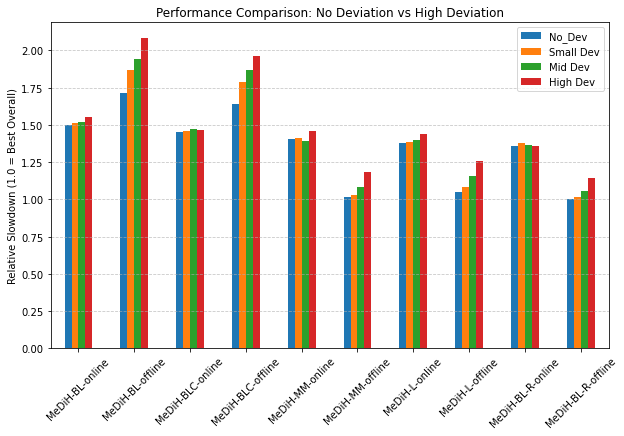

In [93]:
import matplotlib.pyplot as plt

final_comparison.plot(kind='bar', figsize=(10, 6))
plt.title('Performance Comparison: No Deviation vs High Deviation')
plt.ylabel('Relative Slowdown (1.0 = Best Overall)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [110]:
def size_category(size):   
    if size < 200:
        return "Original"
    elif size <= 1000:
        return "Smallest"
    elif size <= 4000:
        return "Small"
    else:
        return "Middle-sized"
    

# Define columns and labels
target_cols = [c for c in merged_df_varOurProcNoDev.columns if c.startswith(('ms_1_', 'ms_2_'))]
label_map = {
 'ms_1_A1': 'MeDiH-BL-online', 'ms_2_A1': 'MeDiH-BL-offline',
    'ms_1_A2': 'MeDiH-BLC-online', 'ms_2_A2': 'MeDiH-BLC-offline',
    'ms_1_A3': 'MeDiH-MM-online', 'ms_2_A3': 'MeDiH-MM-offline',
    'ms_1_A4': 'MeDiH-L-online', 'ms_2_A4': 'MeDiH-L-offline',
    'ms_1_A5': 'MeDiH-BL-R-online', 'ms_2_A5': 'MeDiH-BL-R-offline'
}


def get_grouped_gmeans(df):
    df = df.copy()
    df['category'] = df['size'].apply(size_category)
    
    # Normalize each row individually first (best algorithm in that specific test case = 1.0)
    subset = df[target_cols]
    norm_subset = subset.div(subset.min(axis=1), axis=0)
    
    # Re-attach category and group
    norm_subset['category'] = df['category']
    
    # Calculate Geometric Mean per category
    # .apply(gmean) returns a Series per group, which we transpose to get Algos as rows
    grouped = norm_subset.groupby('category').agg(lambda x: gmean(list(x)))
    return grouped.T.rename(index=label_map)

# 2. Generate the two tables
gmean_no_dev = get_normalized_gmeans(merged_df_varOurProcNoDev)
gmean_small_dev = get_normalized_gmeans(merged_df_varOUrProc10)
gmean_mid_dev = get_normalized_gmeans(merged_df_OurProc30)
gmean_high_dev = get_normalized_gmeans(merged_df_OurProc50)

res_no_dev = get_grouped_gmeans(merged_df_varOurProcNoDev)
res_small_dev = get_grouped_gmeans(merged_df_varOUrProc10)
res_mid_dev = get_grouped_gmeans(merged_df_OurProc30)
res_high_dev = get_grouped_gmeans(merged_df_OurProc50)

# 3. Global Normalization (optional, but keeps 1.0 as the absolute best across all categories)
global_min = min(res_no_dev.min().min(), res_high_dev.min().min())
res_no_dev = res_no_dev / global_min
res_high_dev = res_high_dev / global_min
res_mid_dev = res_mid_dev / global_min
res_small_dev = res_small_dev / global_min

# Display result (e.g., for High Deviation)
print("--- Performance with different deviations per Size Category ---")
print(res_no_dev[['Original', 'Smallest', 'Small', 'Middle-sized']])
print("---------------------------------------\n")
print(res_small_dev[['Original', 'Smallest', 'Small', 'Middle-sized']])
print("---------------------------------------\n")
print(res_high_dev[['Original', 'Smallest', 'Small', 'Middle-sized']])
print("---------------------------------------\n")

print(res_mid_dev[['Original', 'Smallest', 'Small', 'Middle-sized']])


--- Performance with different deviations per Size Category ---
category            Original  Smallest     Small  Middle-sized
MeDiH-BL-online     1.317897  1.747002  1.709835      1.704395
MeDiH-BL-offline    1.243882  1.995815  2.060248      2.048168
MeDiH-BLC-online    1.246191  1.632289  1.706609      1.694232
MeDiH-BLC-offline   1.164395  1.893433  1.974446      1.978996
MeDiH-MM-online     1.124095  1.542248  1.691056      1.673713
MeDiH-MM-offline    1.089629  1.301812  1.063079      1.038410
MeDiH-L-online      1.123045  1.429327  1.696881      1.690302
MeDiH-L-offline     1.140479  1.218029  1.122913      1.156829
MeDiH-BL-R-online   1.058485  1.380502  1.694443      1.708669
MeDiH-BL-R-offline  1.073514  1.141544  1.080506      1.108803
---------------------------------------

category            Original  Smallest     Small  Middle-sized
MeDiH-BL-online     1.382481  1.667747  1.658585      1.891522
MeDiH-BL-offline    1.340660  2.236804  2.061237      2.440139
MeDiH-BLC-onl

In [112]:
import pandas as pd
import numpy as np
from scipy.stats import gmean

# 1. Configuration & Label Mapping
target_cols = [
    'ms_1_A1', 'ms_2_A1', 'ms_1_A2', 'ms_2_A2', 'ms_1_A3', 
    'ms_2_A3', 'ms_1_A4', 'ms_2_A4', 'ms_1_A5', 'ms_2_A5'
]

label_map = {
    'ms_1_A1': 'MeDiH-BL-online',    'ms_2_A1': 'MeDiH-BL-offline',
    'ms_1_A2': 'MeDiH-BLC-online',   'ms_2_A2': 'MeDiH-BLC-offline',
    'ms_1_A3': 'MeDiH-MM-online',    'ms_2_A3': 'MeDiH-MM-offline',
    'ms_1_A4': 'MeDiH-L-online',     'ms_2_A4': 'MeDiH-L-offline',
    'ms_1_A5': 'MeDiH-BL-R-online',  'ms_2_A5': 'MeDiH-BL-R-offline'
}

size_order = ["Original", "Smallest", "Small", "Middle-sized"]

def size_category(size):   
    if size < 200: return "Original"
    elif size <= 1000: return "Smallest"
    elif size <= 4000: return "Small"
    else: return "Middle-sized"

def get_grouped_gmeans(df):
    df = df.copy()
    # Ensure 'size' column is used for categorization
    df['category'] = df['size'].apply(size_category)
    
    # Row-wise normalization: local best = 1.0
    subset = df[target_cols]
    norm_subset = subset.div(subset.min(axis=1), axis=0)
    
    # Re-attach category for grouping
    norm_subset['category'] = df['category']
    
    # Calculate Geometric Mean per category and transpose
    grouped = norm_subset.groupby('category').agg(lambda x: gmean(list(x)))
    return grouped.T.rename(index=label_map)

# 2. Process all Deviation Levels
# (Assuming your merged_df_... variables are already loaded in memory)
res_no_dev    = get_grouped_gmeans(merged_df_varOurProcNoDev)
res_small_dev = get_grouped_gmeans(merged_df_varOUrProc10)
res_mid_dev   = get_grouped_gmeans(merged_df_OurProc30)
res_high_dev  = get_grouped_gmeans(merged_df_OurProc50)

# 3. Global Normalization
# Find the absolute minimum across all data to set a global 1.0 baseline
all_dfs = [res_no_dev, res_small_dev, res_mid_dev, res_high_dev]
global_min = min(d.min().min() for d in all_dfs)

res_no_dev    /= global_min
res_small_dev /= global_min
res_mid_dev   /= global_min
res_high_dev  /= global_min

# 4. Create the "Prettier" Master Table
# This creates a MultiIndex (Level 0: Deviation, Level 1: Size)
combined_master = pd.concat(
    [res_no_dev, res_small_dev, res_mid_dev, res_high_dev], 
    axis=1, 
    keys=['0% Dev', '10% Dev', '30% Dev', '50% Dev']
)

# Sort the rows based on the performance in the 'Original' category of the '0% Dev' scenario
sorted_master = combined_master.sort_values(by=('0% Dev', 'Original'))

# Display the result
print("=== MASTER PERFORMANCE COMPARISON TABLE ===")
print("Sorted by: 0% Deviation -> Original Size")
print("Values represent relative slowdown (1.0 = Best Overall)\n")
# We use .reindex to ensure the size categories appear in our preferred logical order
display_cols = pd.MultiIndex.from_product(
    [['0% Dev', '10% Dev', '30% Dev', '50% Dev'], size_order]
)
print(sorted_master.reindex(columns=display_cols).round(3))

file_name = "Algorithm_Performance_Master_Table.xlsx"

with pd.ExcelWriter(file_name) as writer:
    sorted_master.reindex(columns=display_cols).round(3).to_excel(writer, sheet_name='Performance_Ratios')

print(f"Success! Your master table has been saved as: {file_name}")

=== MASTER PERFORMANCE COMPARISON TABLE ===
Sorted by: 0% Deviation -> Original Size
Values represent relative slowdown (1.0 = Best Overall)

                     0% Dev                               10% Dev           \
                   Original Smallest  Small Middle-sized Original Smallest   
MeDiH-BL-R-online     1.058    1.381  1.694        1.709    1.107    1.414   
MeDiH-BL-R-offline    1.074    1.142  1.081        1.109    1.163    1.154   
MeDiH-MM-offline      1.090    1.302  1.063        1.038    1.182    1.292   
MeDiH-L-online        1.123    1.429  1.697        1.690    1.195    1.382   
MeDiH-MM-online       1.124    1.542  1.691        1.674    1.163    1.492   
MeDiH-L-offline       1.140    1.218  1.123        1.157    1.253    1.221   
MeDiH-BLC-offline     1.164    1.893  1.974        1.979    1.255    2.130   
MeDiH-BL-offline      1.244    1.996  2.060        2.048    1.341    2.237   
MeDiH-BLC-online      1.246    1.632  1.707        1.694    1.311    1.541   


In [ ]:
#--------------------------------------------------------------------------------
#----------------------------------------------------------------------------------
#---------------------------------------------------------------------------------







#-------------------------------------------------------------------------------

In [2]:
def merge_correct_columnsNoMs3(dfsOurVar, lbs):
    renamed_dfs = []
    for df, label in zip(dfsOurVar, lbs):
        # Rename selected columns       
        renamed = df[['wf_name', 'inp_size', 'ms_1', 'ms_2']].copy()
        renamed = renamed.rename(columns={
            'ms_1': f'ms_1_{label}',
            'ms_2': f'ms_2_{label}',           
        })    
        renamed_dfs.append(renamed)


    #print(renamed_dfs)
    # Merge them all on 'wf_name'   
    merged_df = reduce(lambda left, right: pd.merge(left, right, on=['wf_name', 'inp_size']), renamed_dfs)
   # print("MERGED:", merged_df)

    merged_df['size'] = merged_df['wf_name'].str.extract(r'_(\d+)\.')[0].fillna("100")
    merged_df['size'] = merged_df['size'].astype(int)


    for col in merged_df.columns:
        if col.startswith("ms_"):
            merged_df[col] = pd.to_numeric(merged_df[col], errors="coerce")
    
    return merged_df



path = "./output-16-3/merged/*.txt"
print(path)

print("\n-----------------\n 16-03 \n With A4 and A5, all deviations \n  Release enough to fill our processor\n")
patterndevs = r'^(BASE|A\d+)-(ndev)'

dfs=read_dfs(path,patterndevs, 2)
#print(dfs)
labels = ['A1', 'A2', 'A3','A4', 'A5']

dfsVarOurProcNoDev= [dfs[('A1','ndev')], dfs[('A2','ndev')], dfs[('A3','ndev')], dfs[('A4','ndev')], dfs[('A5','ndev')]]#
merged_df_varOurProcNoDev = merge_correct_columnsNoMs3(dfsVarOurProcNoDev, labels)
merged_df_varOurProcNoDev["online_to_offline_A2"] = merged_df_varOurProcNoDev["ms_1_A2"]/merged_df_varOurProcNoDev["ms_2_A2"]
merged_df_varOurProcNoDev["offline_to_base_A2"] = merged_df_varOurProcNoDev["ms_2_A2"]/merged_df_varOurProcNoDev["ms_2_A1"]


merged_df_varOurProcNoDev["online_to_offline_A1"] = merged_df_varOurProcNoDev["ms_1_A1"]/merged_df_varOurProcNoDev["ms_2_A1"]
merged_df_varOurProcNoDev["offline_to_base_A1"] = merged_df_varOurProcNoDev["ms_2_A1"]/merged_df_varOurProcNoDev["ms_2_A1"]
print("online_to_offline_A1", merged_df_varOurProcNoDev["online_to_offline_A1"].agg(gmean))
print("offline_to_base_A1", merged_df_varOurProcNoDev["offline_to_base_A1"].agg(gmean))

patterndevs = r'^(BASE|A\d+)-(\d\ddev)'
dfs=read_dfs(path,patterndevs, 2)




dfsVarOurProc10 = [dfs[('A1','10dev')], dfs[('A2','10dev')], dfs[('A3','10dev')], dfs[('A4','10dev')], dfs[('A5','10dev')]]#print(dfsVar1)
merged_df_varOUrProc10 = merge_correct_columnsNoMs3(dfsVarOurProc10, labels)#print(merged_df_var1)
merged_df_varOUrProc10["online_to_offline_A2"] = merged_df_varOUrProc10["ms_1_A2"]/merged_df_varOUrProc10["ms_2_A2"]
merged_df_varOUrProc10["offline_to_base_A2"] = merged_df_varOUrProc10["ms_2_A2"]/merged_df_varOUrProc10["ms_2_A1"]
print("online_to_offline_A2 10-vars", merged_df_varOUrProc10["online_to_offline_A2"].agg(gmean))
print("offline_to_base_A2 10-vars",merged_df_varOUrProc10["offline_to_base_A2"].agg(gmean))


dfsVarOurProc30 = [dfs[('A1','30dev')], dfs[('A2','30dev')], dfs[('A3','30dev')], dfs[('A4','30dev')], dfs[('A5','30dev')]]
merged_df_OurProc30= merge_correct_columnsNoMs3(dfsVarOurProc30, labels)#print(merged_df_var1)
merged_df_OurProc30["online_to_offline_A2"] = merged_df_OurProc30["ms_1_A2"]/merged_df_OurProc30["ms_2_A2"]
merged_df_OurProc30["offline_to_base_A2"] = merged_df_OurProc30["ms_2_A2"]/merged_df_OurProc30["ms_2_A1"]
print("online_to_offline_A2 30-vars", merged_df_OurProc30["online_to_offline_A2"].agg(gmean))
print("offline_to_base_A2 30-vars",merged_df_OurProc30["offline_to_base_A2"].agg(gmean))


dfsOurProc50 = [dfs[('A1','50dev')], dfs[('A2','50dev')], dfs[('A3','50dev')], dfs[('A4','50dev')], dfs[('A5','50dev')]]
merged_df_OurProc50= merge_correct_columnsNoMs3(dfsOurProc50, labels)
merged_df_OurProc50["online_to_offline_A2"] = merged_df_OurProc50["ms_1_A2"]/merged_df_OurProc50["ms_2_A2"]
merged_df_OurProc50["offline_to_base_A2"] = merged_df_OurProc50["ms_2_A2"]/merged_df_OurProc50["ms_2_A1"]
print("online_to_offline_A2 50-vars", merged_df_OurProc50["online_to_offline_A2"].agg(gmean))
print("offline_to_base_A2 50-vars",merged_df_OurProc50["offline_to_base_A2"].agg(gmean))

print("\n------------------------------------\n")

merged_df_varOurProcNoDev["online_to_offline_A3"] = merged_df_varOurProcNoDev["ms_1_A3"]/merged_df_varOurProcNoDev["ms_2_A3"]
merged_df_varOurProcNoDev["offline_to_base_A3"] = merged_df_varOurProcNoDev["ms_2_A3"]/merged_df_varOurProcNoDev["ms_2_A1"]




print("online_to_offline_A3", merged_df_varOurProcNoDev["online_to_offline_A3"].agg(gmean))
print("offline_to_base_A3", merged_df_varOurProcNoDev["offline_to_base_A3"].agg(gmean))



merged_df_varOUrProc10["online_to_offline_A3"] = merged_df_varOUrProc10["ms_1_A3"]/merged_df_varOUrProc10["ms_2_A3"]
merged_df_varOUrProc10["offline_to_base_A3"] = merged_df_varOUrProc10["ms_2_A3"]/merged_df_varOUrProc10["ms_2_A1"]
print("online_to_offline_A3 10-vars", merged_df_varOUrProc10["online_to_offline_A3"].agg(gmean))
print("offline_to_base_A3 10-vars",merged_df_varOUrProc10["offline_to_base_A3"].agg(gmean))


merged_df_OurProc30["online_to_offline_A3"] = merged_df_OurProc30["ms_1_A3"]/merged_df_OurProc30["ms_2_A3"]
merged_df_OurProc30["offline_to_base_A3"] = merged_df_OurProc30["ms_2_A3"]/merged_df_OurProc30["ms_2_A1"]
print("online_to_offline_A3 30-vars", merged_df_OurProc30["online_to_offline_A3"].agg(gmean))
print("offline_to_base_A3 30-vars",merged_df_OurProc30["offline_to_base_A3"].agg(gmean))


merged_df_OurProc50["online_to_offline_A3"] = merged_df_OurProc50["ms_1_A3"]/merged_df_OurProc50["ms_2_A3"]
merged_df_OurProc50["offline_to_base_A3"] = merged_df_OurProc50["ms_2_A3"]/merged_df_OurProc50["ms_2_A1"]
print("online_to_offline_A3 50-vars", merged_df_OurProc50["online_to_offline_A3"].agg(gmean))
print("offline_to_base_A3 50-vars",merged_df_OurProc50["offline_to_base_A3"].agg(gmean))



print("\n------------------------------------\n")



merged_df_varOurProcNoDev["online_to_offline_A4"] = merged_df_varOurProcNoDev["ms_1_A4"]/merged_df_varOurProcNoDev["ms_2_A4"]
merged_df_varOurProcNoDev["offline_to_base_A4"] = merged_df_varOurProcNoDev["ms_2_A4"]/merged_df_varOurProcNoDev["ms_2_A1"]



print("online_to_offline_A4", merged_df_varOurProcNoDev["online_to_offline_A4"].agg(gmean))
print("offline_to_base_A4", merged_df_varOurProcNoDev["offline_to_base_A4"].agg(gmean))


merged_df_varOUrProc10["online_to_offline_A4"] = merged_df_varOUrProc10["ms_1_A4"]/merged_df_varOUrProc10["ms_2_A4"]
merged_df_varOUrProc10["offline_to_base_A4"] = merged_df_varOUrProc10["ms_2_A4"]/merged_df_varOUrProc10["ms_2_A1"]
print("online_to_offline_A4 10-vars", merged_df_varOUrProc10["online_to_offline_A4"].agg(gmean))
print("offline_to_base_A4 10-vars",merged_df_varOUrProc10["offline_to_base_A4"].agg(gmean))


merged_df_OurProc30["online_to_offline_A4"] = merged_df_OurProc30["ms_1_A4"]/merged_df_OurProc30["ms_2_A4"]
merged_df_OurProc30["offline_to_base_A4"] = merged_df_OurProc30["ms_2_A4"]/merged_df_OurProc30["ms_2_A1"]
print("online_to_offline_A4 30-vars", merged_df_OurProc30["online_to_offline_A4"].agg(gmean))
print("offline_to_base_A4 30-vars",merged_df_OurProc30["offline_to_base_A4"].agg(gmean))


merged_df_OurProc50["online_to_offline_A4"] = merged_df_OurProc50["ms_1_A4"]/merged_df_OurProc50["ms_2_A4"]
merged_df_OurProc50["offline_to_base_A4"] = merged_df_OurProc50["ms_2_A4"]/merged_df_OurProc50["ms_2_A1"]
print("online_to_offline_A4 50-vars", merged_df_OurProc50["online_to_offline_A4"].agg(gmean))
print("offline_to_base_A4 50-vars",merged_df_OurProc50["offline_to_base_A4"].agg(gmean))



print("\n------------------------------------\n")


merged_df_varOurProcNoDev["online_to_offline_A5"] = merged_df_varOurProcNoDev["ms_1_A5"]/merged_df_varOurProcNoDev["ms_2_A5"]
merged_df_varOurProcNoDev["offline_to_base_A5"] = merged_df_varOurProcNoDev["ms_2_A5"]/merged_df_varOurProcNoDev["ms_2_A1"]


print("online_to_offline_A5", merged_df_varOurProcNoDev["online_to_offline_A5"].agg(gmean))
print("offline_to_base_A5", merged_df_varOurProcNoDev["offline_to_base_A5"].agg(gmean))



merged_df_varOUrProc10["online_to_offline_A5"] = merged_df_varOUrProc10["ms_1_A5"]/merged_df_varOUrProc10["ms_2_A5"]
merged_df_varOUrProc10["offline_to_base_A5"] = merged_df_varOUrProc10["ms_2_A5"]/merged_df_varOUrProc10["ms_2_A1"]
print("online_to_offline_A5 10-vars", merged_df_varOUrProc10["online_to_offline_A5"].agg(gmean))
print("offline_to_base_A5 10-vars",merged_df_varOUrProc10["offline_to_base_A5"].agg(gmean))


merged_df_OurProc30["online_to_offline_A5"] = merged_df_OurProc30["ms_1_A5"]/merged_df_OurProc30["ms_2_A5"]
merged_df_OurProc30["offline_to_base_A5"] = merged_df_OurProc30["ms_2_A5"]/merged_df_OurProc30["ms_2_A1"]
print("online_to_offline_A5 30-vars", merged_df_OurProc30["online_to_offline_A5"].agg(gmean))
print("offline_to_base_A5 30-vars",merged_df_OurProc30["offline_to_base_A5"].agg(gmean))


merged_df_OurProc50["online_to_offline_A5"] = merged_df_OurProc50["ms_1_A5"]/merged_df_OurProc50["ms_2_A5"]
merged_df_OurProc50["offline_to_base_A5"] = merged_df_OurProc50["ms_2_A5"]/merged_df_OurProc50["ms_2_A1"]
print("online_to_offline_A5 50-vars", merged_df_OurProc50["online_to_offline_A5"].agg(gmean))
print("offline_to_base_A5 50-vars",merged_df_OurProc50["offline_to_base_A5"].agg(gmean))

./output-16-3/merged/*.txt

-----------------
 16-03 
 With A4 and A5, all deviations 
  Release enough to fill our processor

online_to_offline_A1 0.8444900032072787
offline_to_base_A1 1.0
online_to_offline_A2 10-vars 0.8263626581538829
offline_to_base_A2 10-vars 0.9666784141554707
online_to_offline_A2 30-vars 0.8037006200145342
offline_to_base_A2 30-vars 0.9689788419992016
online_to_offline_A2 50-vars 0.7747547057258685
offline_to_base_A2 50-vars 0.9732077899577447

------------------------------------

online_to_offline_A3 1.4570650294256386
offline_to_base_A3 0.550738923812203
online_to_offline_A3 10-vars 1.385260920379943
offline_to_base_A3 10-vars 0.5668029868358936
online_to_offline_A3 30-vars 1.2955004917724295
offline_to_base_A3 30-vars 0.5789320311676491
online_to_offline_A3 50-vars 1.2796280668562348
offline_to_base_A3 50-vars 0.5794655522847374

------------------------------------

online_to_offline_A4 1.3539520973170975
offline_to_base_A4 0.5836625120613511
online_to_offl

                      No_Dev  Small Dev   Mid Dev  High Dev
MeDiH-MM-offline    1.000000   1.021645  1.070230  1.115123
MeDiH-BL-R-offline  1.006228   1.023043  1.073894  1.113733
MeDiH-L-offline     1.059781   1.086535  1.140486  1.196716
MeDiH-BL-R-online   1.431245   1.388814  1.375805  1.392161
MeDiH-L-online      1.434892   1.408218  1.377427  1.401209
MeDiH-MM-online     1.457065   1.415245  1.386483  1.426943
MeDiH-BLC-online    1.488085   1.439861  1.439654  1.450992
MeDiH-BL-online     1.533376   1.470857  1.469118  1.475551
MeDiH-BLC-offline   1.742394   1.742408  1.791281  1.872841
MeDiH-BL-offline    1.815742   1.802469  1.848628  1.924400


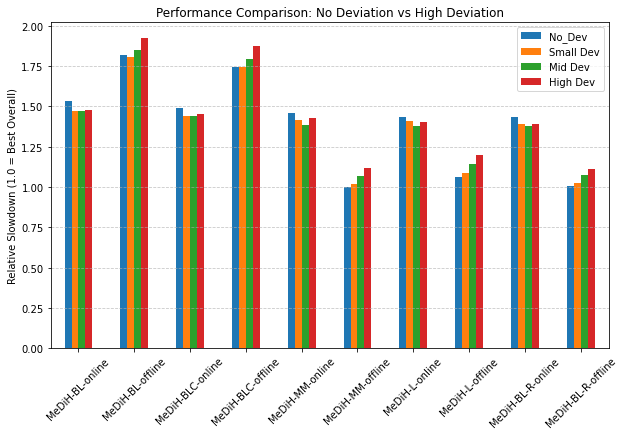

--- Performance with different deviations per Size Category ---
category            Original  Smallest     Small  Middle-sized
MeDiH-BL-online     1.272346  1.777987  1.605236      1.596750
MeDiH-BL-offline    1.186472  2.084833  1.957742      1.954723
MeDiH-BLC-online    1.208021  1.592944  1.601865      1.582464
MeDiH-BLC-offline   1.110653  1.975215  1.876210      1.892392
MeDiH-MM-online     1.104557  1.545807  1.586343      1.566031
MeDiH-MM-offline    1.039339  1.212364  1.010187      1.000000
MeDiH-L-online      1.085246  1.389676  1.591740      1.580483
MeDiH-L-offline     1.087841  1.137486  1.067044      1.107210
MeDiH-BL-R-online   1.066974  1.359811  1.584531      1.591455
MeDiH-BL-R-offline  1.023967  1.068944  1.026747      1.051705
---------------------------------------

category            Original  Smallest     Small  Middle-sized
MeDiH-BL-online     1.305353  1.666411  1.555039      1.520406
MeDiH-BL-offline    1.281321  2.102891  1.960758      1.899514
MeDiH-BLC-onl

In [13]:
import pandas as pd
from scipy.stats import gmean

label_map = {
 'ms_1_A1': 'MeDiH-BL-online', 'ms_2_A1': 'MeDiH-BL-offline',
    'ms_1_A2': 'MeDiH-BLC-online', 'ms_2_A2': 'MeDiH-BLC-offline',
    'ms_1_A3': 'MeDiH-MM-online', 'ms_2_A3': 'MeDiH-MM-offline',
    'ms_1_A4': 'MeDiH-L-online', 'ms_2_A4': 'MeDiH-L-offline',
    'ms_1_A5': 'MeDiH-BL-R-online', 'ms_2_A5': 'MeDiH-BL-R-offline'
}

def get_normalized_gmeans(df):
    # Filter for ms_1 (online) and ms_2 (offline)
    target_cols = [c for c in df.columns if c.startswith(('ms_1_', 'ms_2_'))]
    subset = df[target_cols].copy()
    
    # Row-wise normalization (best in that specific row = 1.0)
    norm_subset = subset.div(subset.min(axis=1), axis=0)
    
    # Calculate Geometric Mean across all rows
    return pd.Series(gmean(norm_subset, axis=0), index=target_cols)

# Calculate for both scenarios
gmean_no_dev = get_normalized_gmeans(merged_df_varOurProcNoDev)
gmean_small_dev = get_normalized_gmeans(merged_df_varOUrProc10)
gmean_mid_dev = get_normalized_gmeans(merged_df_OurProc30)
gmean_high_dev = get_normalized_gmeans(merged_df_OurProc50)

# 2. Combine into one Comparison DataFrame
comparison_df = pd.DataFrame({
    'No_Dev': gmean_no_dev,
    'Small Dev': gmean_small_dev,   
    'Mid Dev': gmean_mid_dev,
     'High Dev': gmean_high_dev,
})

# 3. Global Normalization 
# This makes the "Best Overall" across both scenarios = 1.0
global_min = comparison_df.min().min()
final_comparison = comparison_df / global_min
#final_comparison.index = final_comparison.index.map(label_map)
final_comparison = final_comparison.rename(index=label_map)

print(final_comparison.sort_values(by='No_Dev'))



import matplotlib.pyplot as plt

final_comparison.plot(kind='bar', figsize=(10, 6))
plt.title('Performance Comparison: No Deviation vs High Deviation')
plt.ylabel('Relative Slowdown (1.0 = Best Overall)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


def size_category(size):   
    if size < 200:
        return "Original"
    elif size <= 1000:
        return "Smallest"
    elif size <= 4000:
        return "Small"
    else:
        return "Middle-sized"
    

# Define columns and labels
target_cols = [c for c in merged_df_varOurProcNoDev.columns if c.startswith(('ms_1_', 'ms_2_'))]
label_map = {
 'ms_1_A1': 'MeDiH-BL-online', 'ms_2_A1': 'MeDiH-BL-offline',
    'ms_1_A2': 'MeDiH-BLC-online', 'ms_2_A2': 'MeDiH-BLC-offline',
    'ms_1_A3': 'MeDiH-MM-online', 'ms_2_A3': 'MeDiH-MM-offline',
    'ms_1_A4': 'MeDiH-L-online', 'ms_2_A4': 'MeDiH-L-offline',
    'ms_1_A5': 'MeDiH-BL-R-online', 'ms_2_A5': 'MeDiH-BL-R-offline'
}


def get_grouped_gmeans(df):
    df = df.copy()
    df['category'] = df['size'].apply(size_category)
    
    # Normalize each row individually first (best algorithm in that specific test case = 1.0)
    subset = df[target_cols]
    norm_subset = subset.div(subset.min(axis=1), axis=0)
    
    # Re-attach category and group
    norm_subset['category'] = df['category']
    
    # Calculate Geometric Mean per category
    # .apply(gmean) returns a Series per group, which we transpose to get Algos as rows
    grouped = norm_subset.groupby('category').agg(lambda x: gmean(list(x)))
    return grouped.T.rename(index=label_map)

# 2. Generate the two tables
gmean_no_dev = get_normalized_gmeans(merged_df_varOurProcNoDev)
gmean_small_dev = get_normalized_gmeans(merged_df_varOUrProc10)
gmean_mid_dev = get_normalized_gmeans(merged_df_OurProc30)
gmean_high_dev = get_normalized_gmeans(merged_df_OurProc50)

res_no_dev = get_grouped_gmeans(merged_df_varOurProcNoDev)
res_small_dev = get_grouped_gmeans(merged_df_varOUrProc10)
res_mid_dev = get_grouped_gmeans(merged_df_OurProc30)
res_high_dev = get_grouped_gmeans(merged_df_OurProc50)

# 3. Global Normalization (optional, but keeps 1.0 as the absolute best across all categories)
global_min = min(res_no_dev.min().min(), res_high_dev.min().min())
res_no_dev = res_no_dev / global_min
res_high_dev = res_high_dev / global_min
res_mid_dev = res_mid_dev / global_min
res_small_dev = res_small_dev / global_min

# Display result (e.g., for High Deviation)
print("--- Performance with different deviations per Size Category ---")
print(res_no_dev[['Original', 'Smallest', 'Small', 'Middle-sized']])
print("---------------------------------------\n")
print(res_small_dev[['Original', 'Smallest', 'Small', 'Middle-sized']])
print("---------------------------------------\n")
print(res_high_dev[['Original', 'Smallest', 'Small', 'Middle-sized']])
print("---------------------------------------\n")

print(res_mid_dev[['Original', 'Smallest', 'Small', 'Middle-sized']])






import pandas as pd
import numpy as np
from scipy.stats import gmean

# 1. Configuration & Label Mapping
target_cols = [
    'ms_1_A1', 'ms_2_A1', 'ms_1_A2', 'ms_2_A2', 'ms_1_A3', 
    'ms_2_A3', 'ms_1_A4', 'ms_2_A4', 'ms_1_A5', 'ms_2_A5'
]

label_map = {
    'ms_1_A1': 'MeDiH-BL-online',    'ms_2_A1': 'MeDiH-BL-offline',
    'ms_1_A2': 'MeDiH-BLC-online',   'ms_2_A2': 'MeDiH-BLC-offline',
    'ms_1_A3': 'MeDiH-MM-online',    'ms_2_A3': 'MeDiH-MM-offline',
    'ms_1_A4': 'MeDiH-L-online',     'ms_2_A4': 'MeDiH-L-offline',
    'ms_1_A5': 'MeDiH-BL-R-online',  'ms_2_A5': 'MeDiH-BL-R-offline'
}

size_order = ["Original", "Smallest", "Small", "Middle-sized"]

def size_category(size):   
    if size < 200: return "Original"
    elif size <= 1000: return "Smallest"
    elif size <= 4000: return "Small"
    else: return "Middle-sized"

def get_grouped_gmeans(df):
    df = df.copy()
    # Ensure 'size' column is used for categorization
    df['category'] = df['size'].apply(size_category)
    
    # Row-wise normalization: local best = 1.0
    subset = df[target_cols]
    norm_subset = subset.div(subset.min(axis=1), axis=0)
    
    # Re-attach category for grouping
    norm_subset['category'] = df['category']
    
    # Calculate Geometric Mean per category and transpose
    grouped = norm_subset.groupby('category').agg(lambda x: gmean(list(x)))
    return grouped.T.rename(index=label_map)

# 2. Process all Deviation Levels
# (Assuming your merged_df_... variables are already loaded in memory)
res_no_dev    = get_grouped_gmeans(merged_df_varOurProcNoDev)
res_small_dev = get_grouped_gmeans(merged_df_varOUrProc10)
res_mid_dev   = get_grouped_gmeans(merged_df_OurProc30)
res_high_dev  = get_grouped_gmeans(merged_df_OurProc50)

# 3. Global Normalization
# Find the absolute minimum across all data to set a global 1.0 baseline
all_dfs = [res_no_dev, res_small_dev, res_mid_dev, res_high_dev]
global_min = min(d.min().min() for d in all_dfs)

res_no_dev    /= global_min
res_small_dev /= global_min
res_mid_dev   /= global_min
res_high_dev  /= global_min

# 4. Create the "Prettier" Master Table
# This creates a MultiIndex (Level 0: Deviation, Level 1: Size)
combined_master = pd.concat(
    [res_no_dev, res_small_dev, res_mid_dev, res_high_dev], 
    axis=1, 
    keys=['0% Dev', '10% Dev', '30% Dev', '50% Dev']
)

# Sort the rows based on the performance in the 'Original' category of the '0% Dev' scenario
sorted_master = combined_master.sort_values(by=('0% Dev', 'Original'))

# Display the result
print("=== MASTER PERFORMANCE COMPARISON TABLE ===")
print("Sorted by: 0% Deviation -> Original Size")
print("Values represent relative slowdown (1.0 = Best Overall)\n")
# We use .reindex to ensure the size categories appear in our preferred logical order
display_cols = pd.MultiIndex.from_product(
    [['0% Dev', '10% Dev', '30% Dev', '50% Dev'], size_order]
)
print(sorted_master.reindex(columns=display_cols).round(3))

file_name = "Algorithm_Performance_Master_Table.xlsx"

with pd.ExcelWriter(file_name) as writer:
    sorted_master.reindex(columns=display_cols).round(3).to_excel(writer, sheet_name='Performance_Ratios')

print(f"Success! Your master table has been saved as: {file_name}")

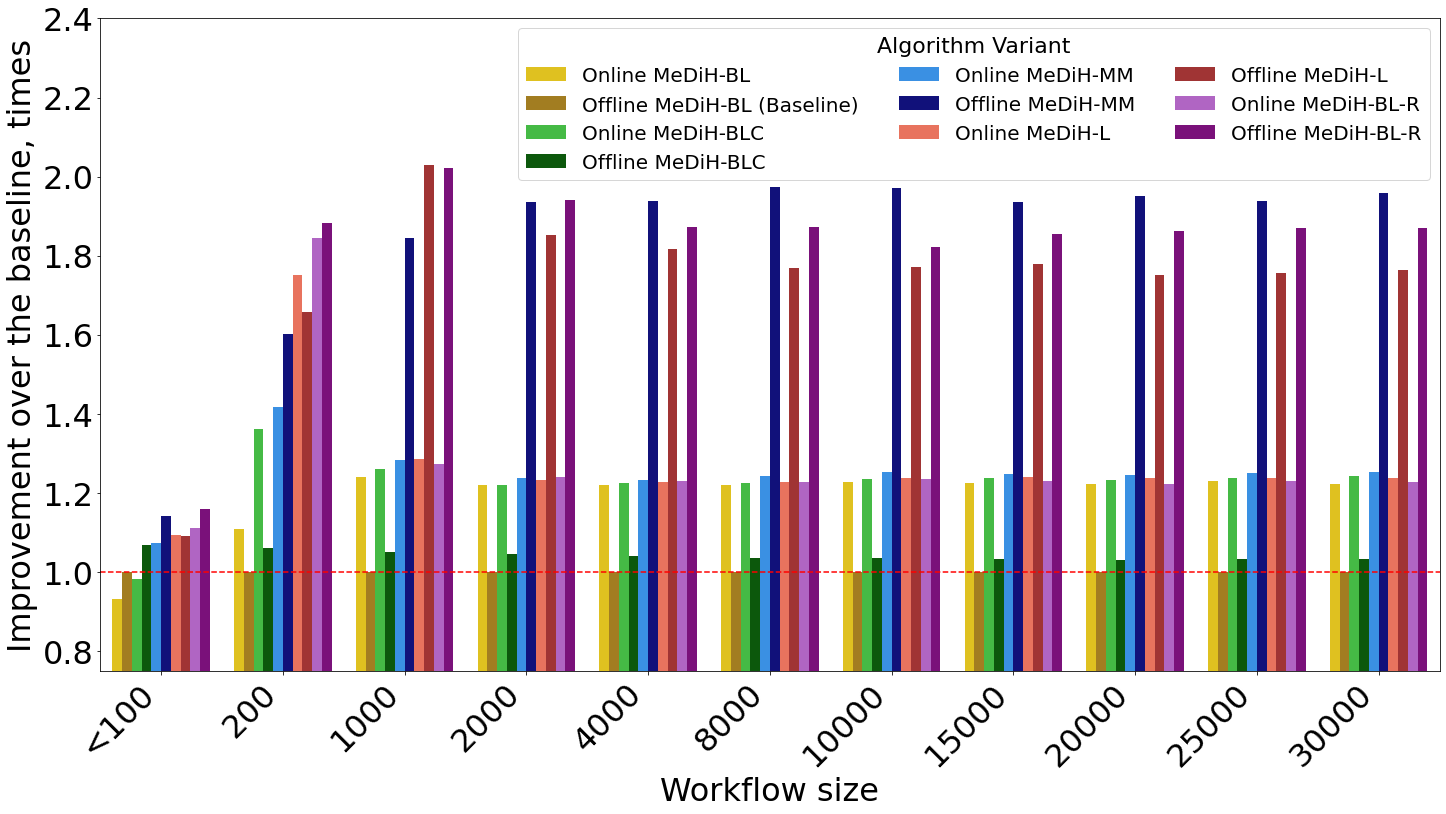

      size                    alg_rel     ratio
0      100     MeDiH-BL - dyn_vs_base  0.932507
1      100    MeDiH-BL - stat_vs_base  1.000000
2      100   MeDiH-BL-R - dyn_vs_base  1.111998
3      100  MeDiH-BL-R - stat_vs_base  1.158702
4      100    MeDiH-BLC - dyn_vs_base  0.982162
..     ...                        ...       ...
105  30000   MeDiH-BLC - stat_vs_base  1.031877
106  30000      MeDiH-L - dyn_vs_base  1.237385
107  30000     MeDiH-L - stat_vs_base  1.764669
108  30000     MeDiH-MM - dyn_vs_base  1.252131
109  30000    MeDiH-MM - stat_vs_base  1.957513

[110 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base       1.184147
MeDiH-BL - stat_vs_base      1.000000
MeDiH-BL-R - dyn_vs_base     1.268646
MeDiH-BL-R - stat_vs_base    1.804504
MeDiH-BLC - dyn_vs_base      1.220188
MeDiH-BLC - stat_vs_base     1.042096
MeDiH-L - dyn_vs_base        1.265421
MeDiH-L - stat_vs_base       1.713319
MeDiH-MM - dyn_vs_base       1.246164
MeDiH-MM - stat_vs_base      1.815742
Name: ratio,

In [47]:
%run NewChartsCommon.ipynb
plot_df_nodev = buld_plot_df(merged_df_varOurProcNoDev)

plotDynAndStaticVsBaseNoInset(plot_df_nodev,"no deviations", "title",['stat_vs_base', 'dyn_vs_base'])

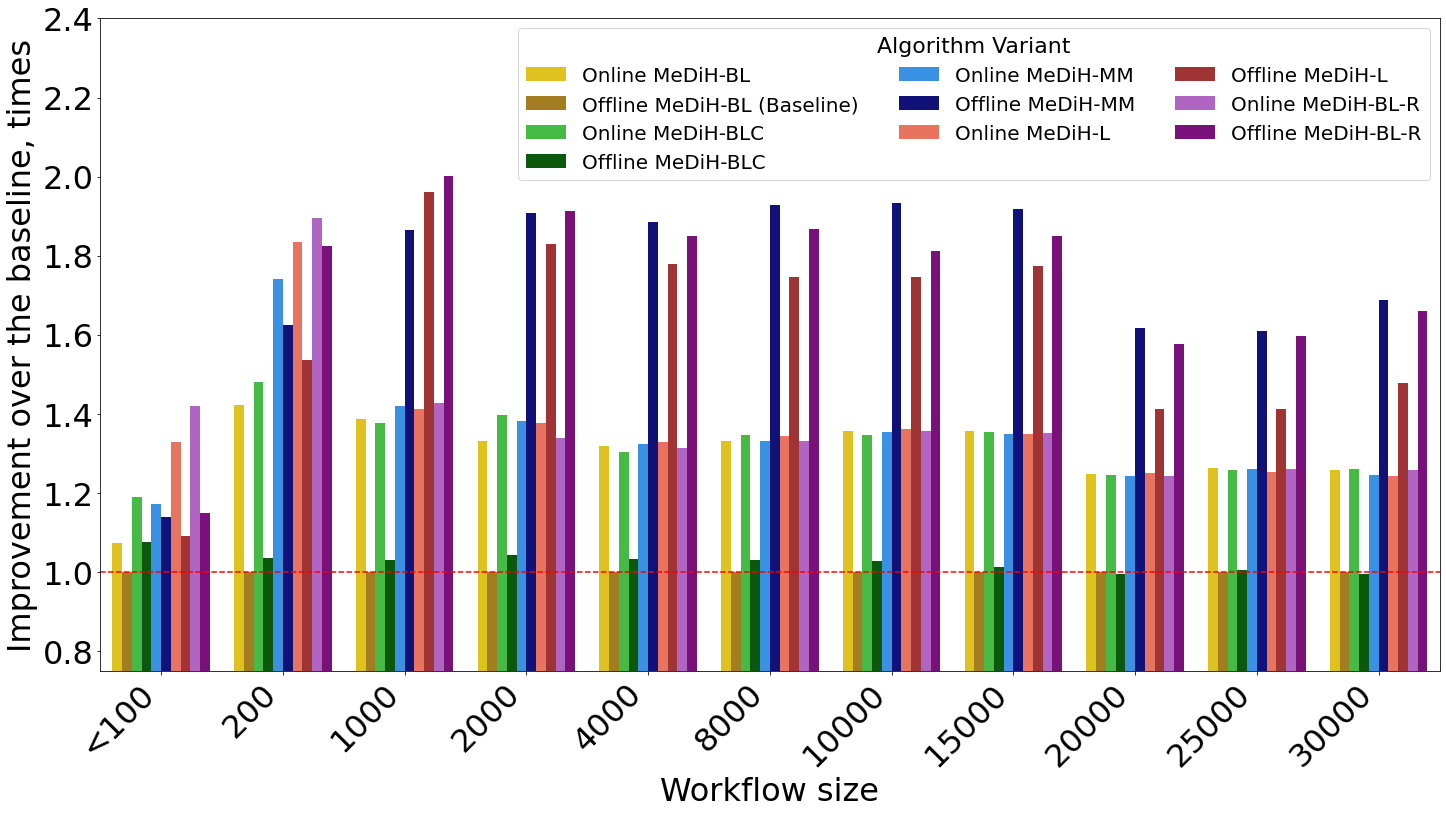

      size                    alg_rel     ratio
0      100     MeDiH-BL - dyn_vs_base  1.073388
1      100    MeDiH-BL - stat_vs_base  1.000000
2      100   MeDiH-BL-R - dyn_vs_base  1.419040
3      100  MeDiH-BL-R - stat_vs_base  1.149542
4      100    MeDiH-BLC - dyn_vs_base  1.188423
..     ...                        ...       ...
105  30000   MeDiH-BLC - stat_vs_base  0.995119
106  30000      MeDiH-L - dyn_vs_base  1.243646
107  30000     MeDiH-L - stat_vs_base  1.478138
108  30000     MeDiH-MM - dyn_vs_base  1.246241
109  30000    MeDiH-MM - stat_vs_base  1.687467

[110 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base       1.300671
MeDiH-BL - stat_vs_base      1.000000
MeDiH-BL-R - dyn_vs_base     1.372047
MeDiH-BL-R - stat_vs_base    1.719559
MeDiH-BLC - dyn_vs_base      1.320824
MeDiH-BLC - stat_vs_base     1.025190
MeDiH-L - dyn_vs_base        1.363404
MeDiH-L - stat_vs_base       1.595115
MeDiH-MM - dyn_vs_base       1.340819
MeDiH-MM - stat_vs_base      1.719961
Name: ratio,

In [48]:
%run NewChartsCommon.ipynb
plot_df_nodev = buld_plot_df(merged_df_OurProc50)

plotDynAndStaticVsBaseNoInset(plot_df_nodev,"large deviations", "title",['stat_vs_base', 'dyn_vs_base'])